In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from n00ter_stats import * 
from n00_config_params import *
from n00bis_config_analysis_functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

/home/jules.granget/myenvs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# FUNCTIONS

In [3]:
def get_ROI_counts(df):

    ROI_list = df['ROI'].unique()

    ROI_counts_plot = {}
    ROI_counts_sujet = {}

    for ROI in ROI_list:

        ROI_counts_plot[ROI] = 0
        ROI_counts_sujet[ROI] = len(df.query(f"ROI == '{ROI}'")['sujet'].unique())

        for sujet in df.query(f"ROI == '{ROI}'")['sujet'].unique():

            ROI_counts_plot[ROI] += df.query(f"ROI == '{ROI}' and sujet == '{sujet}'")['chan'].unique().shape[0]
        
    return ROI_counts_plot, ROI_counts_sujet

In [4]:
def get_pval(pval):

    if pval > 0.05:

        return pval

    elif pval < 0.001:

        return '***'

    elif pval < 0.01:

        return '**'

    elif pval < 0.05:

        return '*'

# LOAD DF

## Cxy

In [5]:
os.chdir(os.path.join(path_results, 'allplot', 'df', 'df_aggregates'))
df_Cxy = pd.read_excel(f'df_Cxy.xlsx', index_col = 0).drop(columns = 'Unnamed: 0')

In [6]:
df_Cxy_FR_CV = df_Cxy.query(f"cond == 'FR_CV'")

#### params filter
min_sujet = 2
min_plot_ROI = 6

ROI_filt_plot_count = df_Cxy_FR_CV.groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_plot_ROI}")['ROI'].unique() 
ROI_filt_sujet_count = df_Cxy_FR_CV.groupby(['ROI', 'sujet']).size().reset_index(name='count').groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_sujet}")['ROI'].unique() 
df_Cxy_FR_CV_filt = df_Cxy_FR_CV.query(f"ROI in {ROI_filt_plot_count.tolist()} and ROI in {ROI_filt_sujet_count.tolist()}")

In [7]:
df_ROI_count_FR_CV = df_Cxy_FR_CV_filt.groupby(['ROI']).size().reset_index(name='count_plot')
df_ROI_count_FR_CV['count_sujet'] = df_Cxy_FR_CV_filt.groupby(['ROI', 'sujet']).size().reset_index(name='count_sujet').groupby('ROI').size().reset_index(name='count_sujet')['count_sujet'].values

ROI_list_FR_CV_filt = df_Cxy_FR_CV_filt['ROI'].unique()

In [8]:
df_Cxy_allcond = df_Cxy.query(f"sujet in {sujet_list}")

#### params filter
min_sujet = 2
min_plot_ROI = 1

ROI_filt_plot_count = df_Cxy_allcond.groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_plot_ROI}")['ROI'].unique() 
ROI_filt_sujet_count = df_Cxy_allcond.groupby(['ROI', 'sujet']).size().reset_index(name='count').groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_sujet}")['ROI'].unique() 
df_Cxy_allcond_filt = df_Cxy_allcond.query(f"ROI in {ROI_filt_plot_count.tolist()} and ROI in {ROI_filt_sujet_count.tolist()}")

df_ROI_count_allcond = df_Cxy_allcond_filt.groupby(['ROI']).size().reset_index(name='count_plot')
df_ROI_count_allcond['count_sujet'] = df_Cxy_allcond_filt.groupby(['ROI', 'sujet']).size().reset_index(name='count_sujet').groupby('ROI').size().reset_index(name='count_sujet')['count_sujet'].values

ROI_list_allcond_filt = df_Cxy_allcond_filt['ROI'].unique()

## Pxx

In [9]:
os.chdir(os.path.join(path_results, 'allplot', 'df', 'df_aggregates'))
df_Pxx = pd.read_excel(f'df_Pxx.xlsx', index_col = 0).drop(columns = 'Unnamed: 0')

In [10]:
df_Pxx_FR_CV = df_Pxx.query(f"cond == 'FR_CV'")

#### params filter
min_sujet = 2
min_plot_ROI = 6

ROI_filt_plot_count = df_Pxx_FR_CV.groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_plot_ROI}")['ROI'].unique() 
ROI_filt_sujet_count = df_Pxx_FR_CV.groupby(['ROI', 'sujet']).size().reset_index(name='count').groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_sujet}")['ROI'].unique() 
df_Pxx_FR_CV_filt = df_Pxx_FR_CV.query(f"ROI in {ROI_filt_plot_count.tolist()} and ROI in {ROI_filt_sujet_count.tolist()}")

ROI_list_FR_CV_filt = df_Pxx_FR_CV_filt['ROI'].unique()

In [11]:
df_Pxx_allcond = df_Pxx.query(f"sujet in {sujet_list}")

#### params filter
min_sujet = 2
min_plot_ROI = 1

ROI_filt_plot_count = df_Pxx_allcond.groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_plot_ROI}")['ROI'].unique() 
ROI_filt_sujet_count = df_Pxx_allcond.groupby(['ROI', 'sujet']).size().reset_index(name='count').groupby(['ROI']).size().reset_index(name='count').query(f"count >= {min_sujet}")['ROI'].unique() 
df_Pxx_allcond_filt = df_Pxx_allcond.query(f"ROI in {ROI_filt_plot_count.tolist()} and ROI in {ROI_filt_sujet_count.tolist()}")

ROI_list_allcond_filt = df_Pxx_allcond_filt['ROI'].unique()

# ANATOMY

## FR_CV

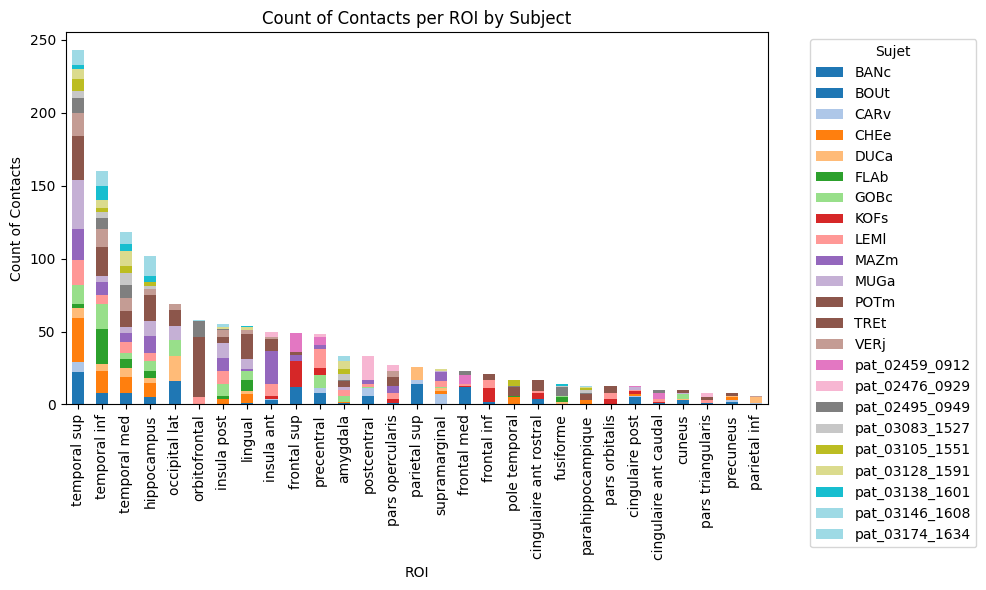

In [7]:
roi_counts = df_Cxy_FR_CV_filt.query("ROI != 'WM'").groupby(['ROI', 'sujet']).size().reset_index(name='count')
roi_pivot = roi_counts.pivot(index='ROI', columns='sujet', values='count').fillna(0)
roi_pivot = roi_pivot.loc[roi_pivot.sum(axis=1).sort_values(ascending=False).index]

ax = roi_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='tab20')

plt.title('Count of Contacts per ROI by Subject')
plt.xlabel('ROI')
plt.ylabel('Count of Contacts')
plt.legend(title='Sujet', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## ALLCOND

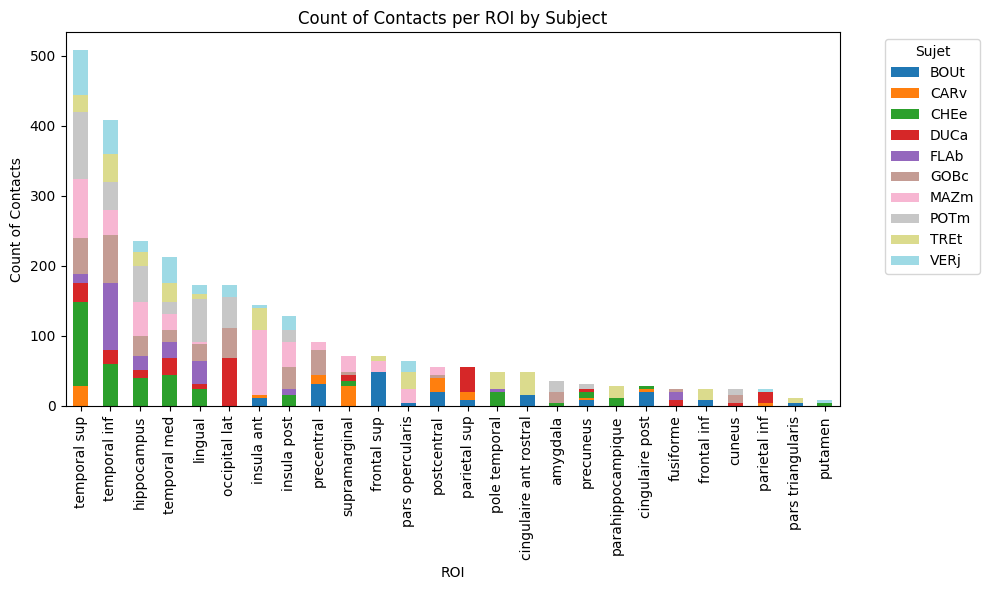

In [ ]:
roi_counts = df_Cxy_allcond_filt.query("ROI != 'WM'").groupby(['ROI', 'sujet']).size().reset_index(name='count')
roi_pivot = roi_counts.pivot(index='ROI', columns='sujet', values='count').fillna(0)
roi_pivot = roi_pivot.loc[roi_pivot.sum(axis=1).sort_values(ascending=False).index]

ax = roi_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='tab20')

plt.title('Count of Contacts per ROI by Subject')
plt.xlabel('ROI')
plt.ylabel('Count of Contacts')
plt.legend(title='Sujet', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cxy

## FR_CV

### PROPORTION

In [10]:
data_df = {'ROI' : [], 'Cxy_p' : []}

for ROI in ROI_list_FR_CV_filt:
    
    signi = (df_Cxy_FR_CV.query(f"ROI == '{ROI}'")['Cxy'] > df_Cxy_FR_CV.query(f"ROI == '{ROI}'")['Cxy_surr']).sum()
    prop_Cxy = signi/df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    
    data_df['ROI'].append(ROI)
    data_df['Cxy_p'].append(prop_Cxy)

df_Cxy_p = pd.DataFrame(data_df) 
df_Cxy_p

,ROI,Cxy_p
0,temporal sup,0.160494
1,amygdala,0.393939
2,temporal med,0.144068
3,hippocampus,0.137255
4,temporal inf,0.243750
5,parahippocampique,0.384615
6,pole temporal,0.117647
7,insula post,0.109091
8,lingual,0.148148
9,WM,0.294807


/tmp/ipykernel_218168/3009641518.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(data=df_plot , x='Cxy_p', y='ROI', ax=ax, join=False, order=df_plot.sort_values('Cxy_p').ROI)


Text(0.5, 1.0, 'FR_CV Cxy_p')

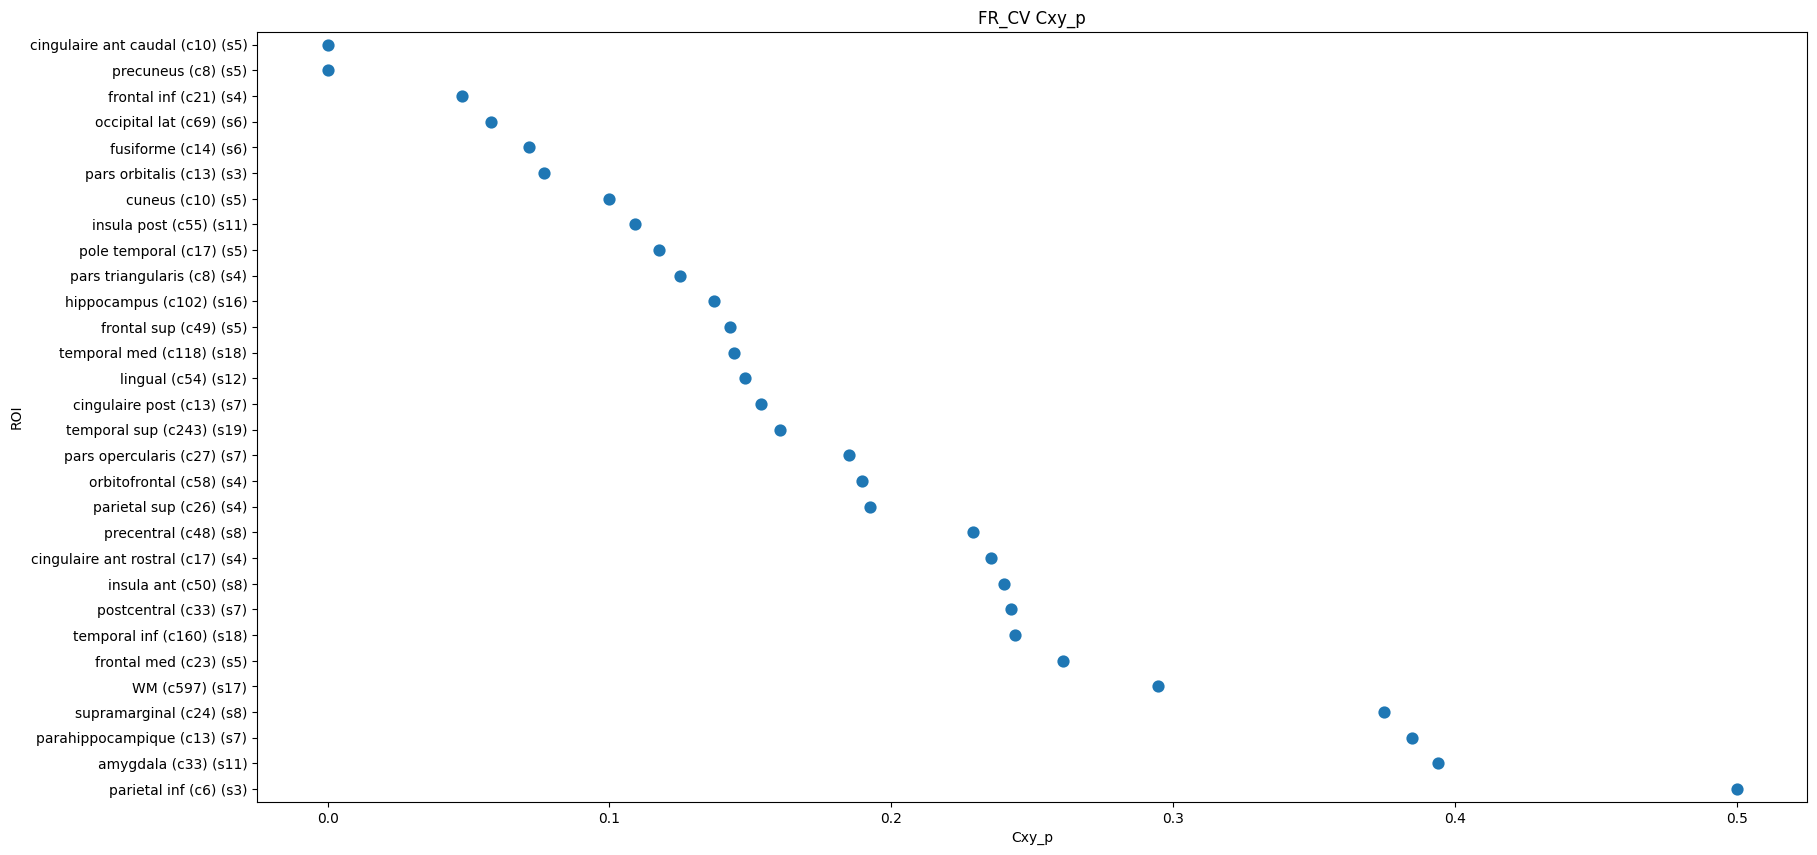

In [14]:
df_plot = df_Cxy_p

fig, ax = plt.subplots(figsize = (20,10))
g = sns.pointplot(data=df_plot , x='Cxy_p', y='ROI', ax=ax, join=False, order=df_plot.sort_values('Cxy_p').ROI)

ROI_labels = []

for ROI in df_plot.sort_values('Cxy_p').ROI:

    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f'{ROI} (c{_count_plot}) (s{_count_sujet})')

g.set_yticks(range(len(ROI_labels)))
g.set_yticklabels(ROI_labels)
ax.tick_params(axis='y')

ax.set_title('FR_CV Cxy_p')

/tmp/ipykernel_218168/1374946785.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(data=df_plot , x='Cxy_p', y='ROI', ax=ax, join=False, order=df_plot.sort_values('Cxy_p').ROI)


Text(0.5, 1.0, 'FR_CV Cxy_p')

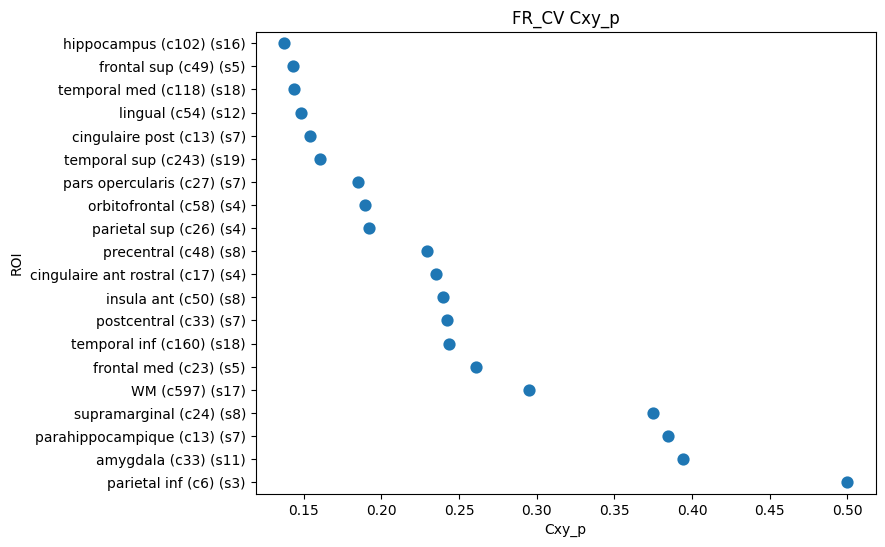

In [18]:
df_plot = df_Cxy_p.sort_values('Cxy_p').iloc[-20:]

fig, ax = plt.subplots(figsize = (8,6))
g = sns.pointplot(data=df_plot , x='Cxy_p', y='ROI', ax=ax, join=False, order=df_plot.sort_values('Cxy_p').ROI)

ROI_labels = []

for ROI in df_plot.sort_values('Cxy_p').ROI:

    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f'{ROI} (c{_count_plot}) (s{_count_sujet})')

g.set_yticks(range(len(ROI_labels)))
g.set_yticklabels(ROI_labels)
ax.tick_params(axis='y')

ax.set_title('FR_CV Cxy_p')

### OLS subject wise

In [30]:
df_Cxy_FR_CV_subjectwise = df_Cxy_FR_CV_filt[['ROI', 'sujet', 'Cxy', 'resp']].groupby(['ROI', 'sujet']).median().reset_index()

In [33]:
data = {'ROI' : [], 'coeff' : [], 'intercept' : [], 'pval' : [], 'p' : []}

for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV_subjectwise.query(f"ROI == '{ROI}'")[['Cxy', 'resp']]

    x = _df_lmm['resp']
    y = _df_lmm['Cxy']

    x = sm.add_constant(x)

    mdl = sm.OLS(y, x).fit()
    mdl_fit = mdl.predict(x) 

    coeff = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[-1]
    intercept = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[0]
    pval = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['P>|t|'].values[-1]

    if pval < 0.05:

        p = 1

    else:

        p = 0

    data['ROI'].append(ROI)
    data['coeff'].append(coeff)
    data['intercept'].append(intercept)
    data['pval'].append(pval)
    data['p'].append(p)

    
    # fig, axs = plt.subplots(ncols=2, figsize=(10,5))

    # sns.histplot(mdl_fit.resid, ax=axs[0])
    # sm.qqplot(mdl_fit.resid, dist=stats.norm, line='s', ax=axs[1])

    # plt.suptitle(f"{ROI}")

    # fig.savefig(os.path.join(path_results, 'allplot', 'allcond', 'PSD_Coh', 'stats', f'{ROI}_qqplot_distrib_LMM_FR_CV_Cxy.png'))

    # plt.close()

    # plt.show()


df_lmm = pd.DataFrame(data)

/home/jules.granget/myenvs/py311/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
/tmp/ipykernel_218168/2788892720.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  coeff = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[-1]
/home/jules.granget/myenvs/py311/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
/tmp/ipykernel_218168/2788892720.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a liter

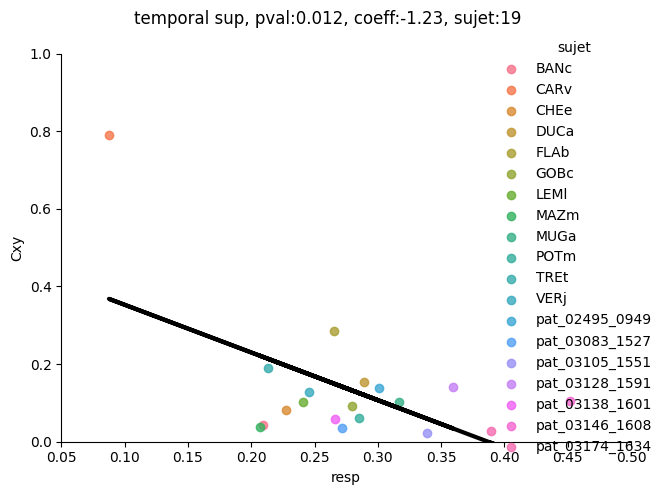

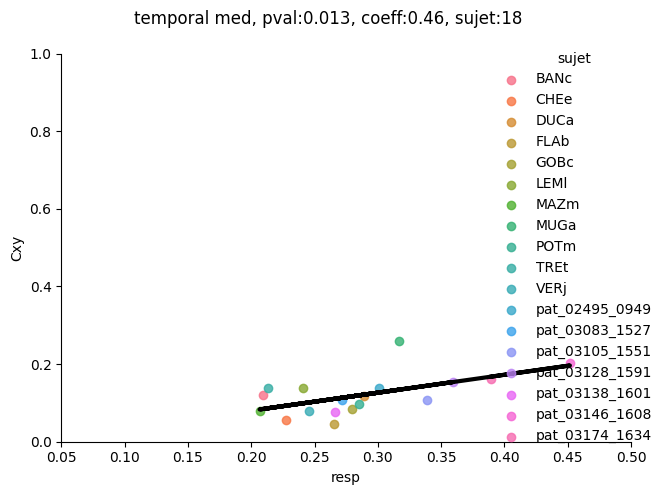

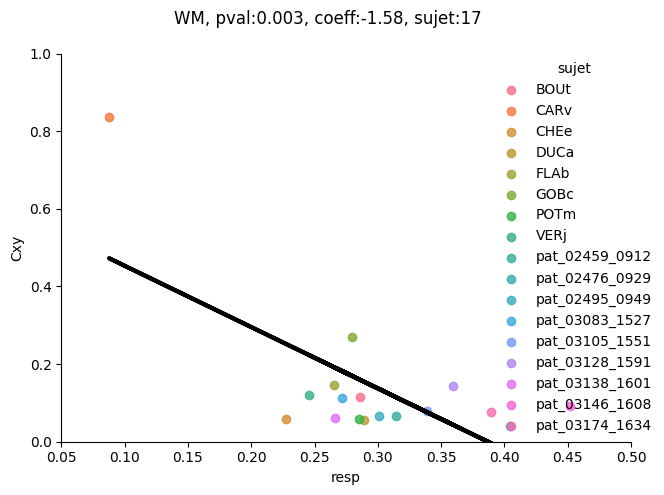

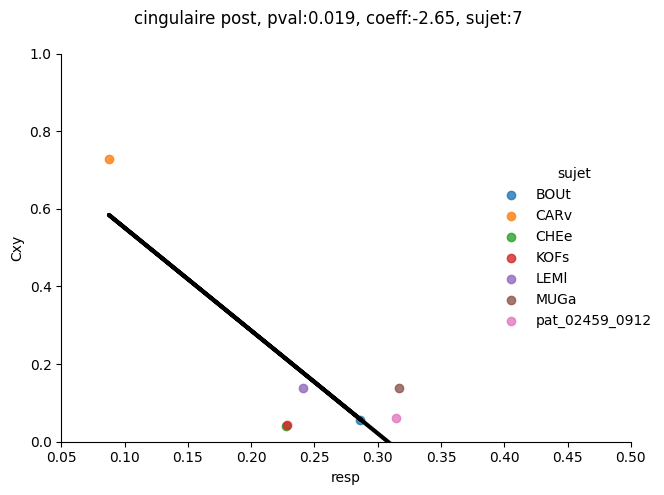

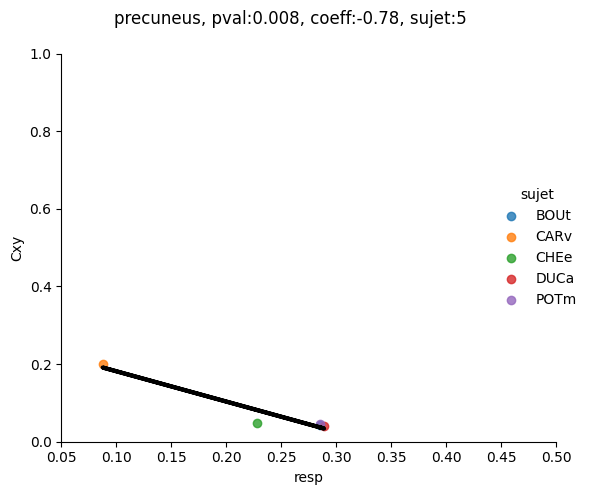

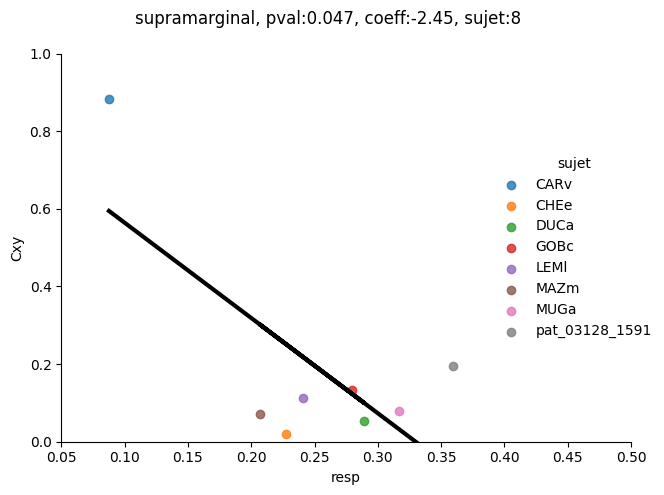

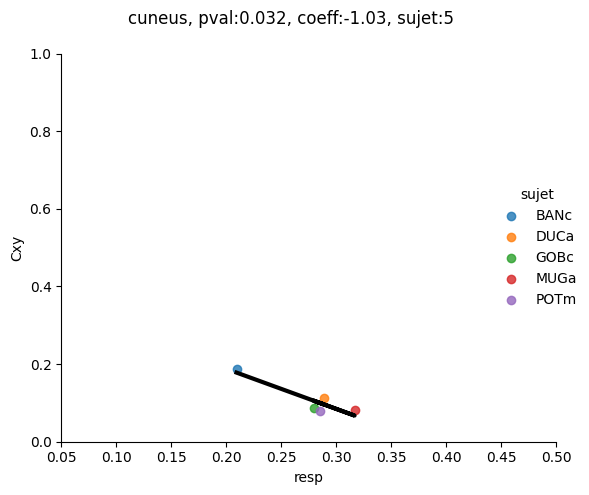

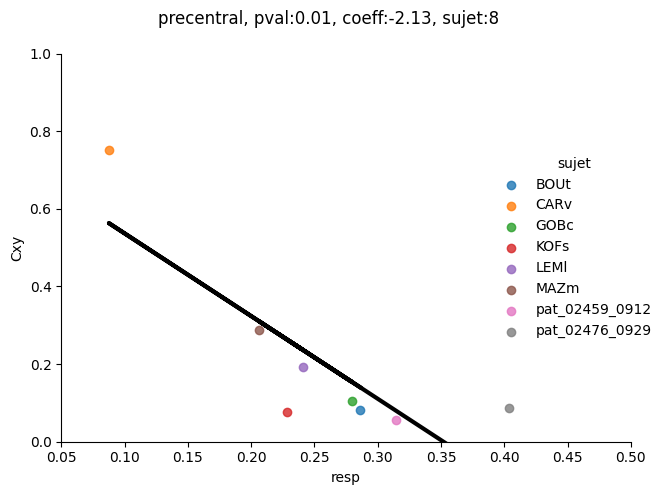

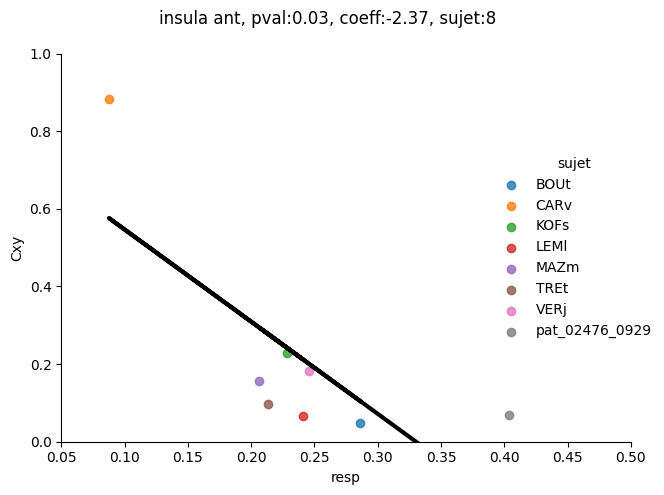

In [34]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV_subjectwise.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if df_lmm.query(f"ROI == '{ROI}'")['p'].values != 1:
        continue
    
    pval = df_lmm.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(data=_df_lmm, x="resp", y="Cxy", hue='sujet')
    _coeff = df_lmm.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_lmm['resp'].values*_coeff + df_lmm.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    plt.plot(_df_lmm['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f'{ROI} (c{_count_plot}) (s{_count_sujet})')
    plt.suptitle(f"{ROI}, pval:{pval}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

/home/jules.granget/myenvs/py311/lib/python3.11/site-packages/seaborn/axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


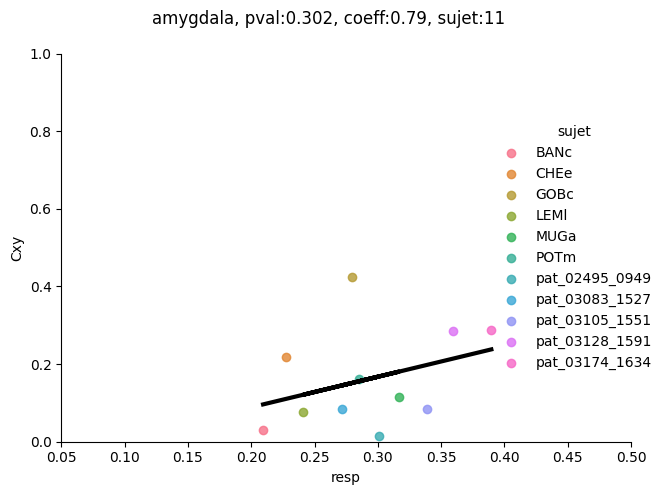

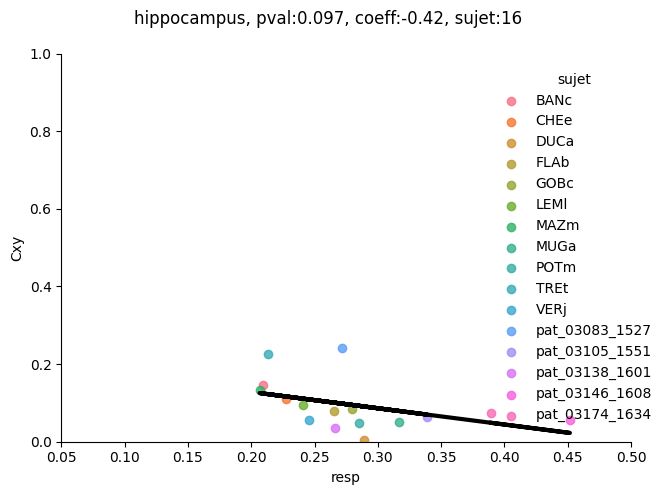

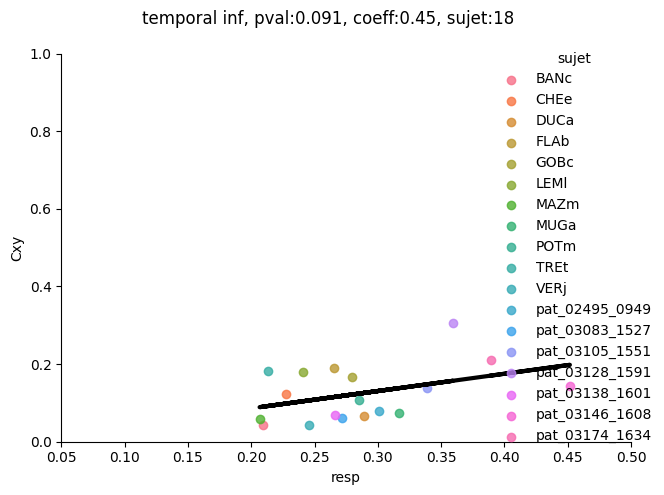

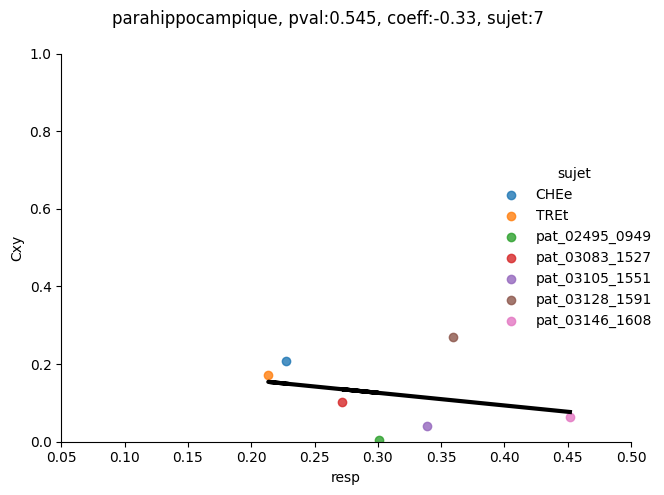

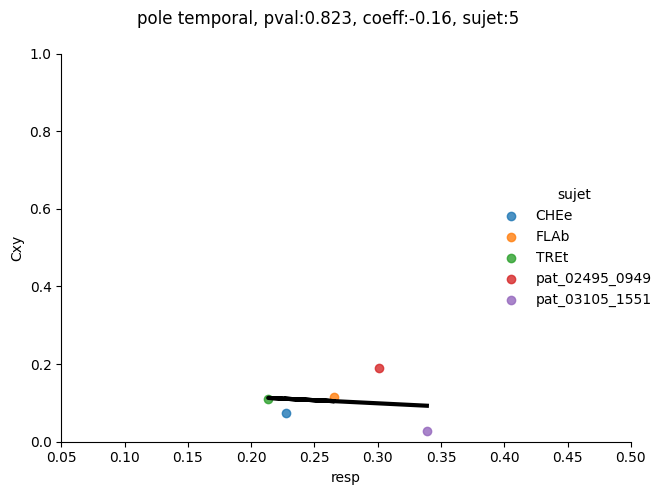

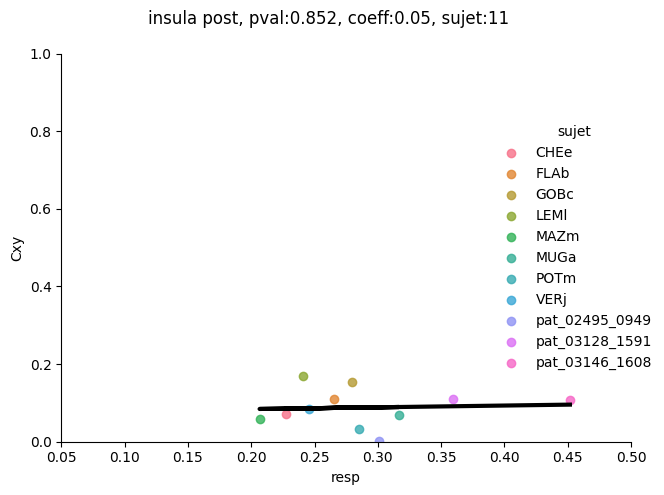

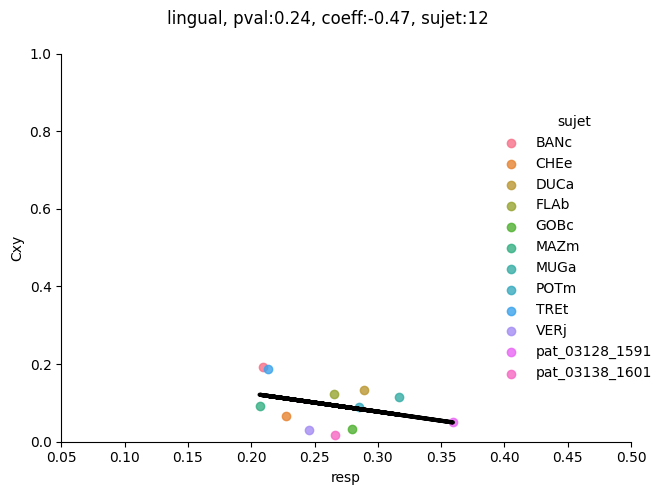

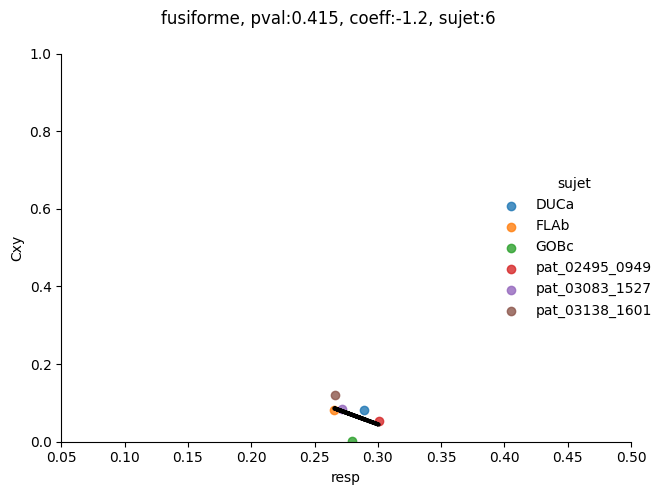

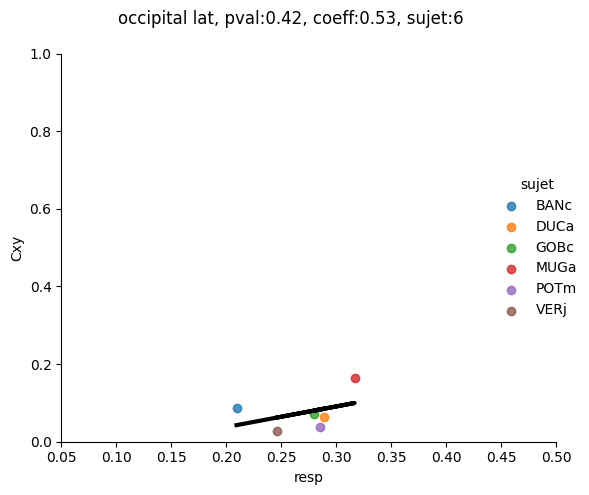

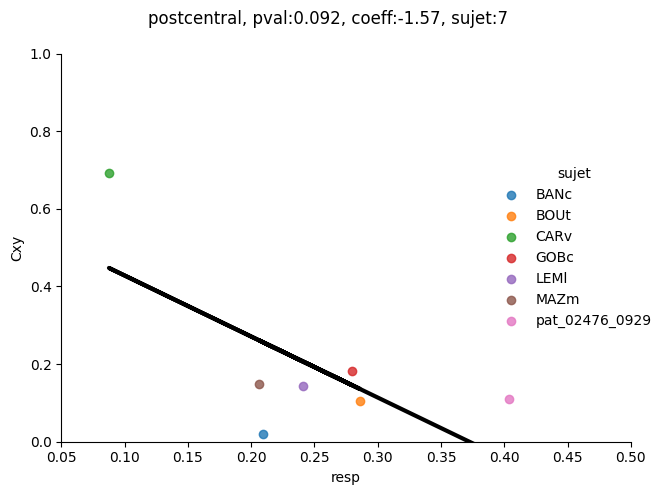

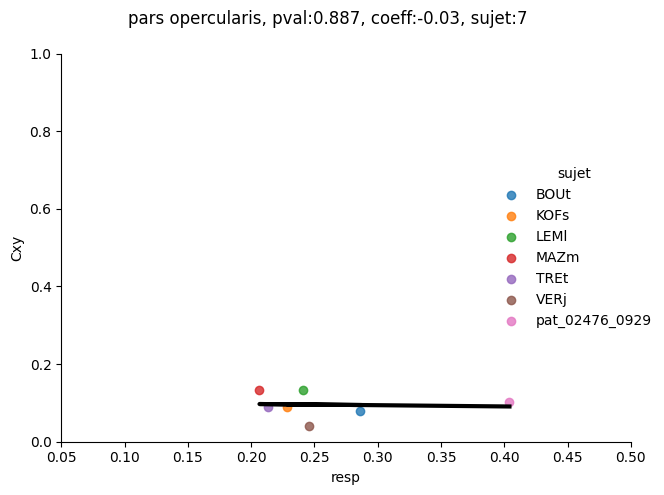

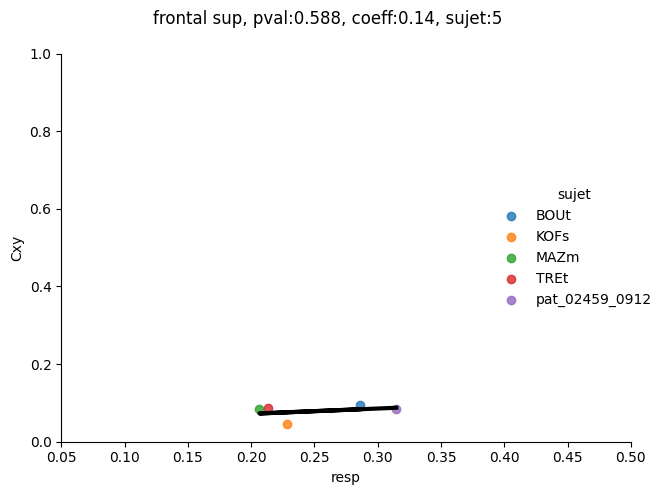

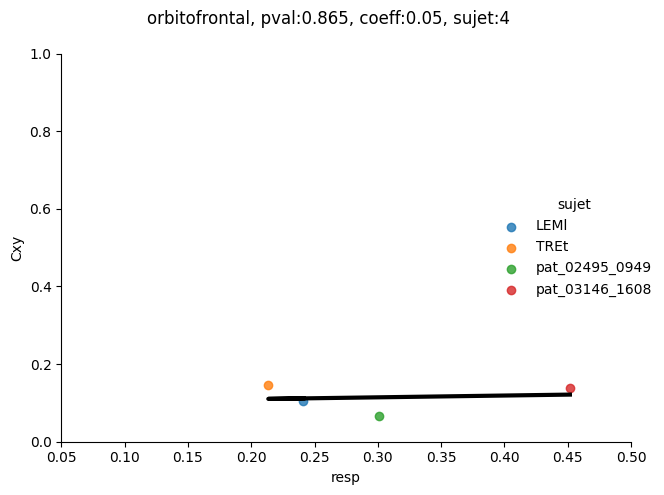

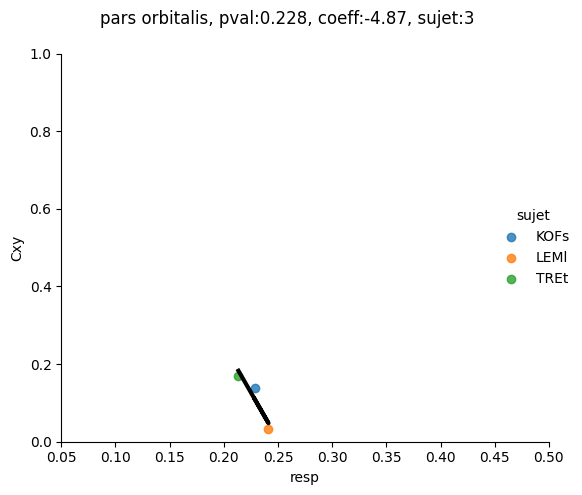

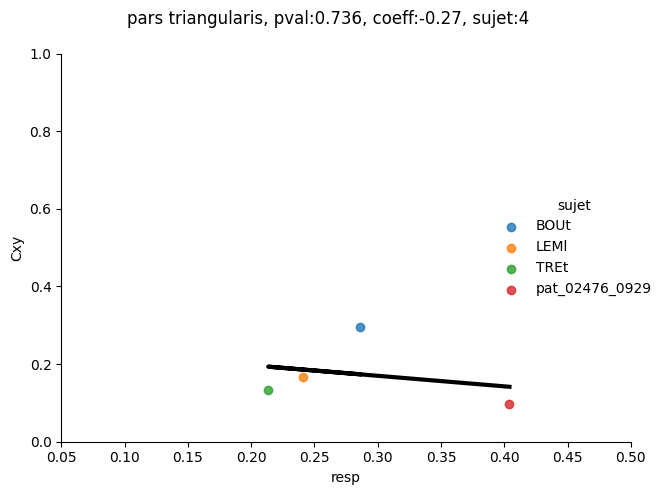

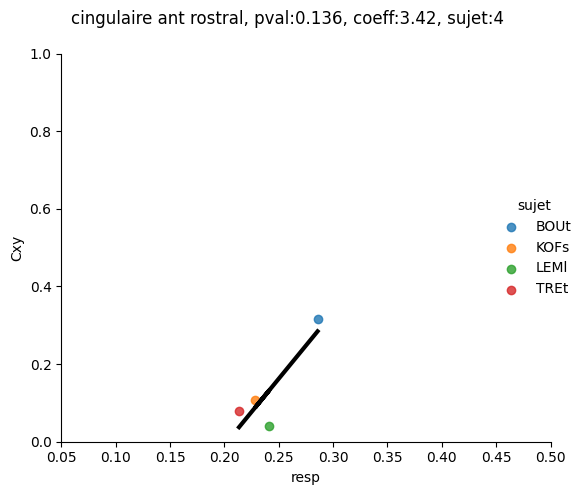

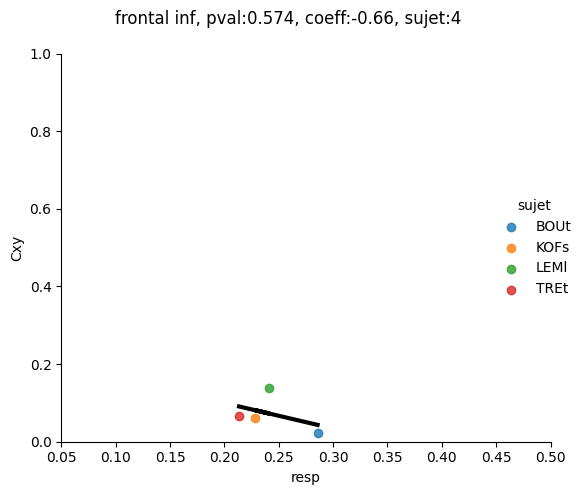

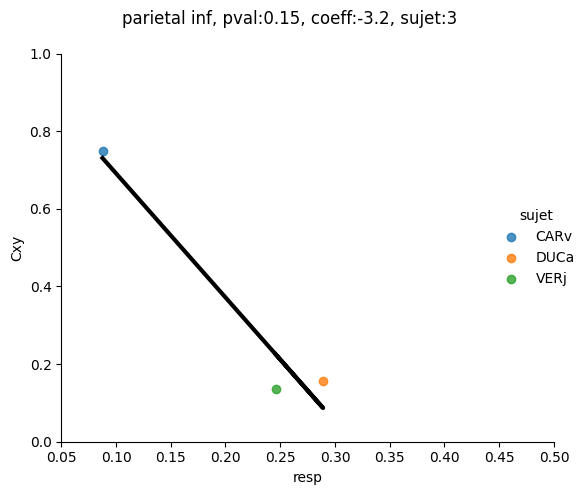

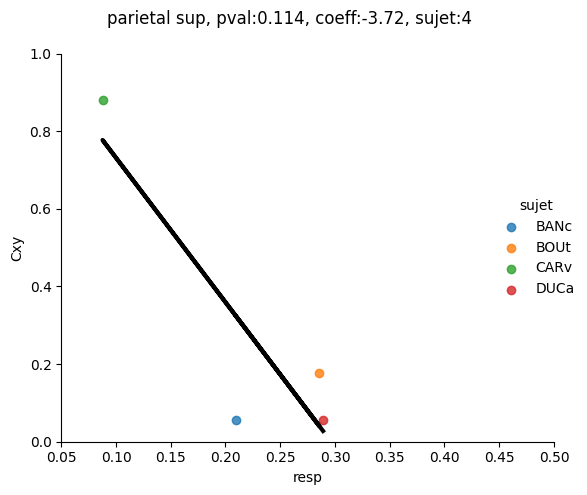

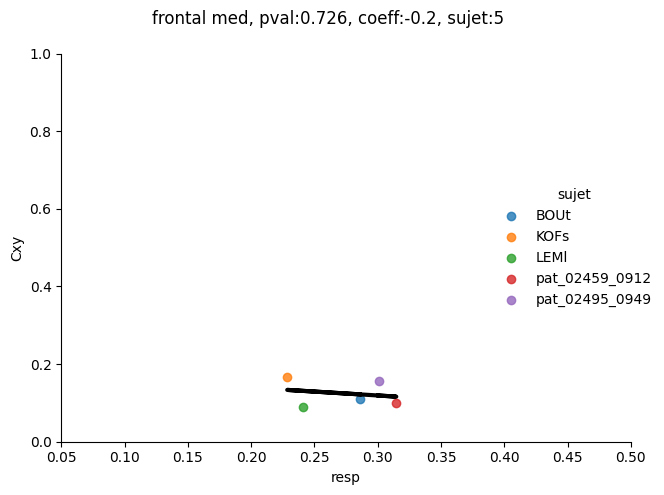

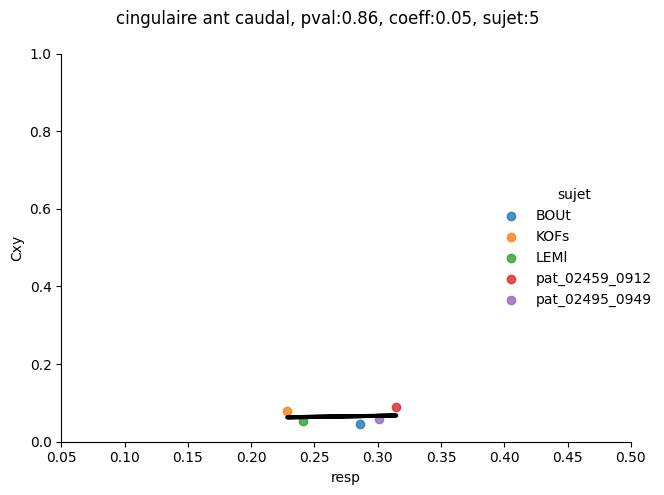

In [36]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV_subjectwise.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if df_lmm.query(f"ROI == '{ROI}'")['p'].values == 1:
        continue
    
    pval = df_lmm.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(data=_df_lmm, x="resp", y="Cxy", hue='sujet')
    _coeff = df_lmm.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_lmm['resp'].values*_coeff + df_lmm.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    plt.plot(_df_lmm['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, pval:{pval}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

### Spearman allplot

In [ ]:
def spearman_permutation_test(x, y, n_perm, percentile_thresh_list):

    rho_obs, _ = scipy.stats.spearmanr(x, y)

    null_dist = np.zeros(n_perm)
    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        null_dist[i], _ = scipy.stats.spearmanr(x, y_perm)

    signi = rho_obs > np.percentile(null_dist, percentile_thresh_list[1]) or rho_obs < np.percentile(null_dist, percentile_thresh_list[0])

    return rho_obs, signi

percentile_thresh_list = [2.5, 97.5]
n_perm_spearman = 500

data = {'ROI': [], 'rho': [], 'signi': []}

for ROI in ROI_list_FR_CV_filt:

    _df = df_Cxy_FR_CV_filt.query(f"ROI == '{ROI}'")[['Cxy', 'resp']]

    x = _df['resp'].values
    y = _df['Cxy'].values

    rho, signi = spearman_permutation_test(x, y, n_perm_spearman, percentile_thresh_list)

    data['ROI'].append(ROI)
    data['rho'].append(rho)
    data['signi'].append(signi)

# Build dataframe
df_spearman = pd.DataFrame(data)



In [ ]:
df_spearman.query(f"signi == True").sort_values('rho', ascending=False)

,ROI,rho,signi
24,cingulaire ant rostral,0.495914,True
1,amygdala,0.399034,True
3,hippocampus,-0.313424,True
16,precentral,-0.410537,True
18,insula ant,-0.423400,True
21,orbitofrontal,-0.428323,True
17,postcentral,-0.462940,True
9,WM,-0.468516,True
12,supramarginal,-0.496906,True
22,pars orbitalis,-0.687209,True


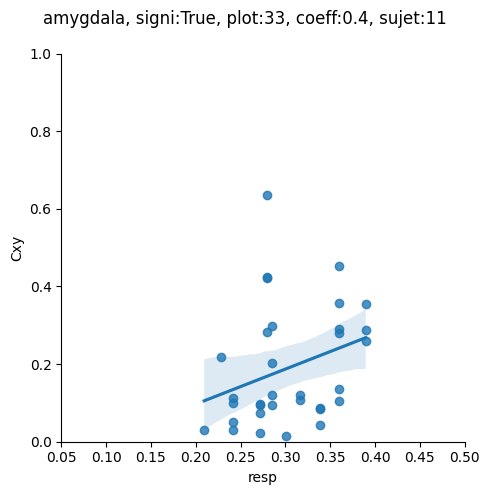

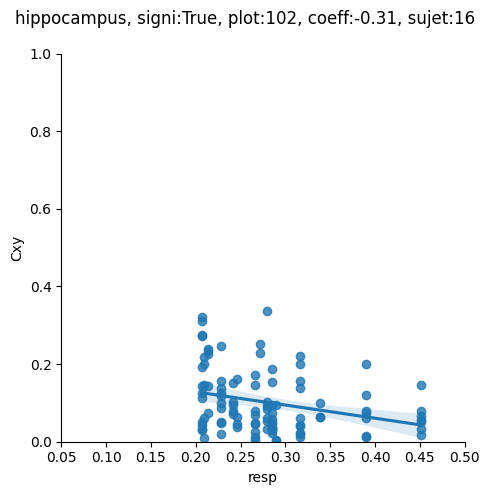

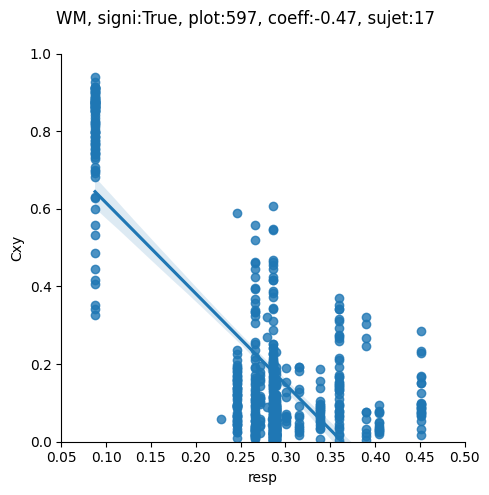

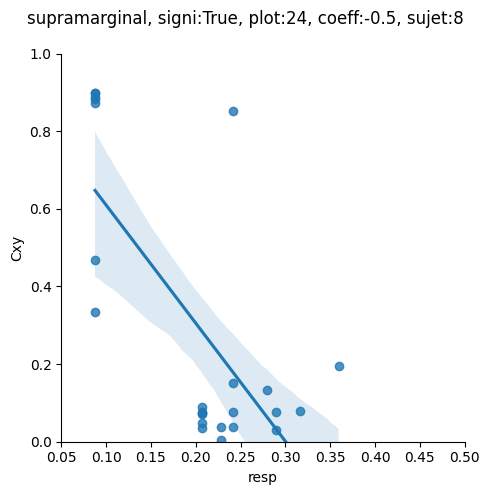

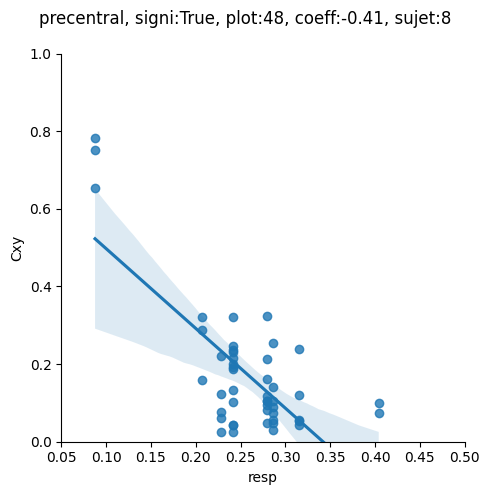

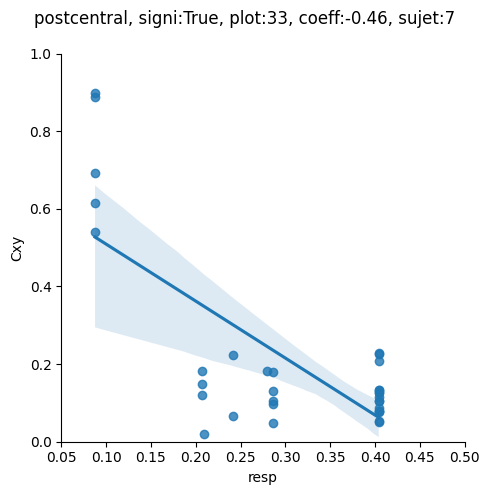

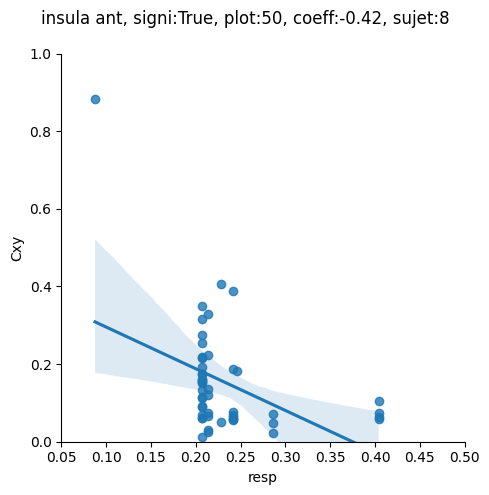

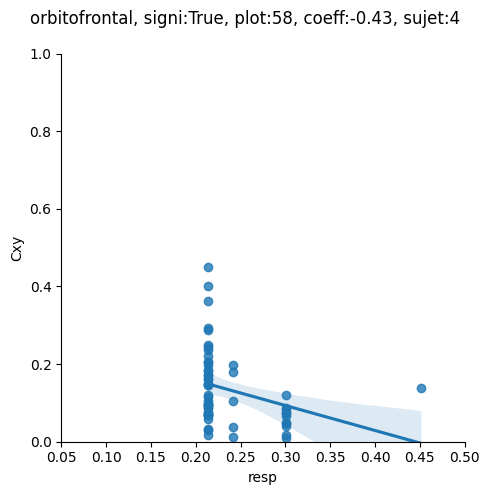

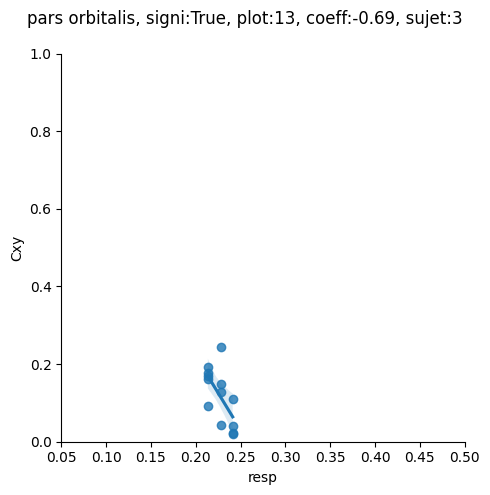

In [ ]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if _df_lmm.query(f"ROI == '{ROI}'")['signi'].values != True:
        continue
    
    pval = df_spearman.query(f"ROI == '{ROI}'")['signi'].values[0]
    sns.lmplot(x="resp", y="Cxy", data=df_spearman)
    _coeff = df_spearman.query(f"ROI == '{ROI}'")['rho'].values[0]
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, signi:{pval}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

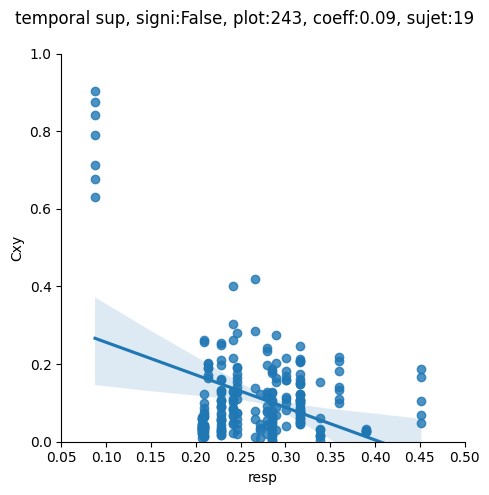

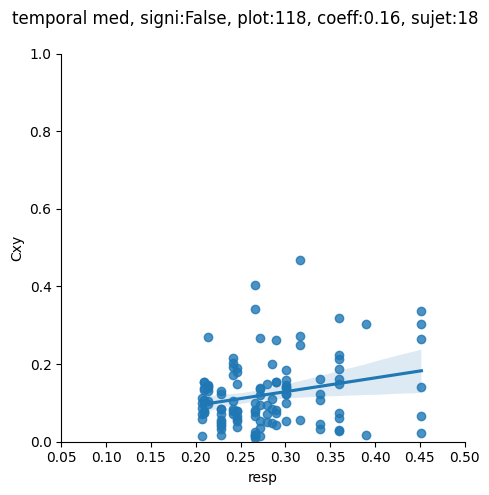

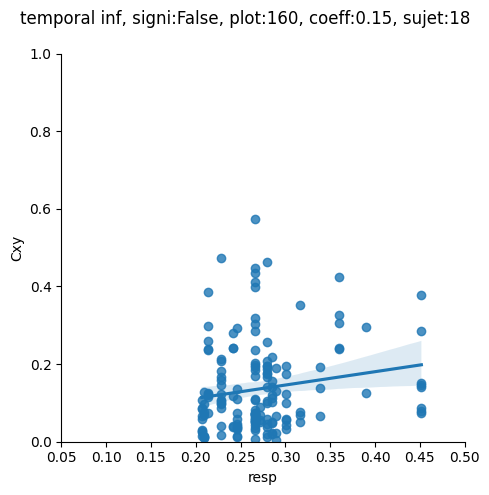

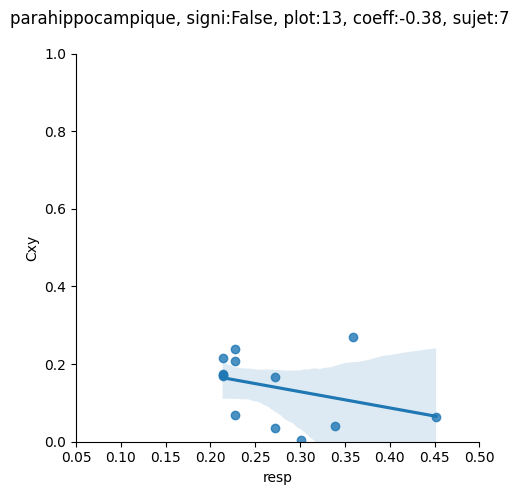

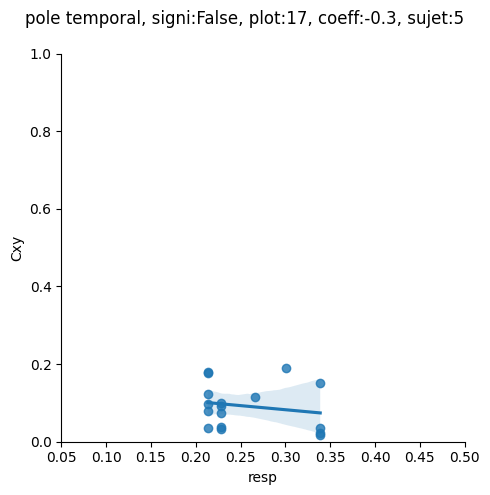

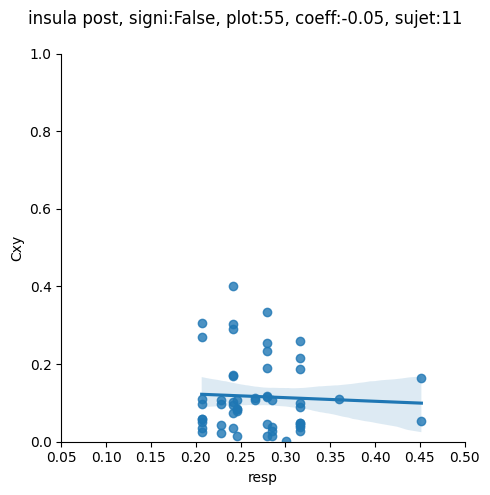

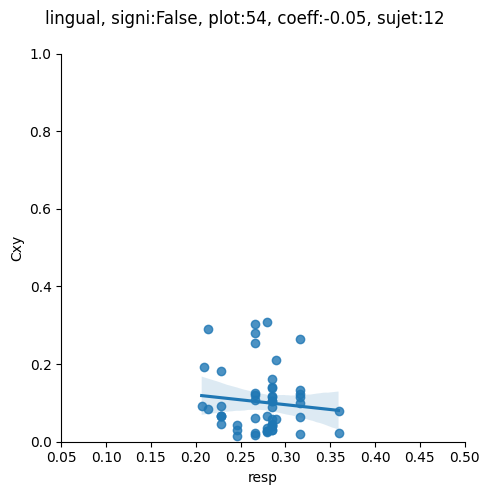

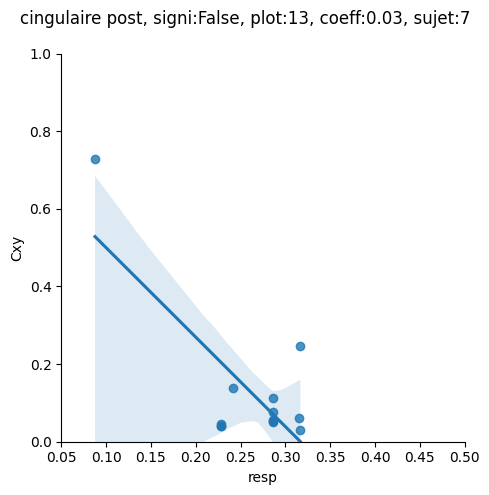

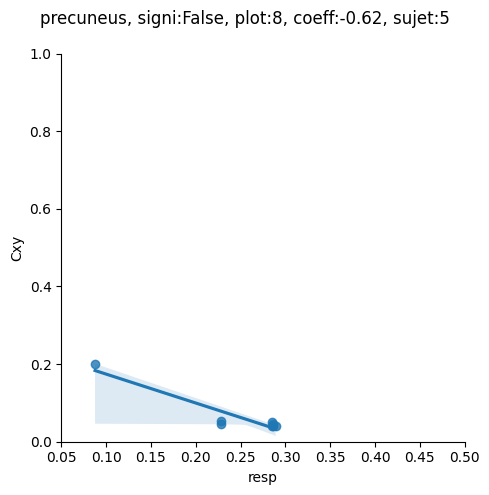

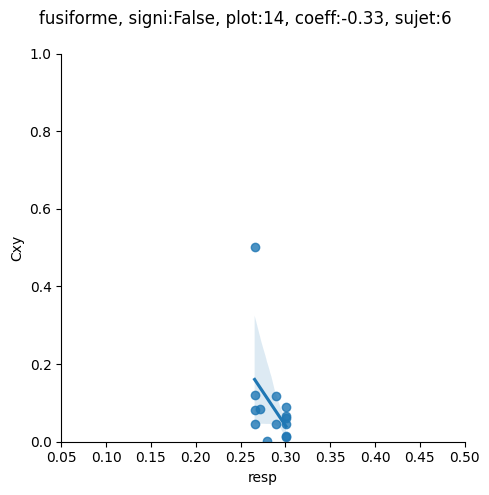

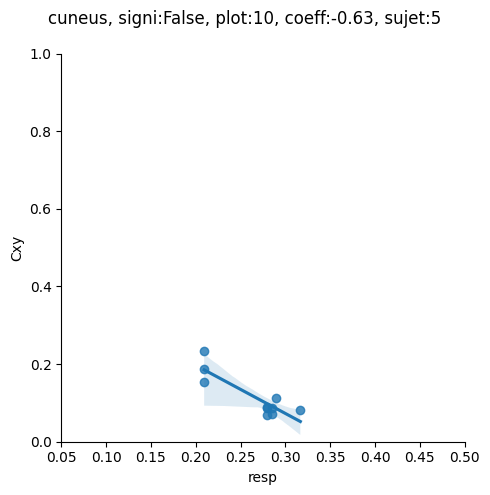

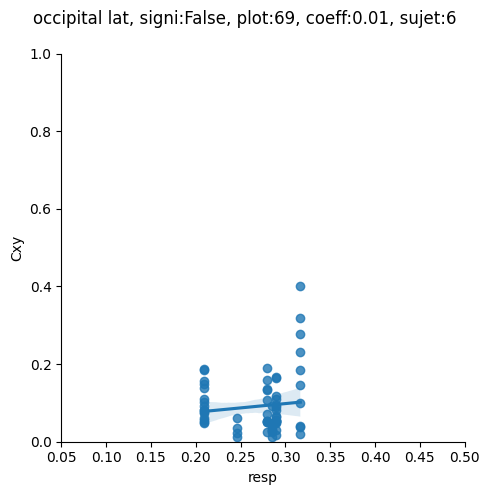

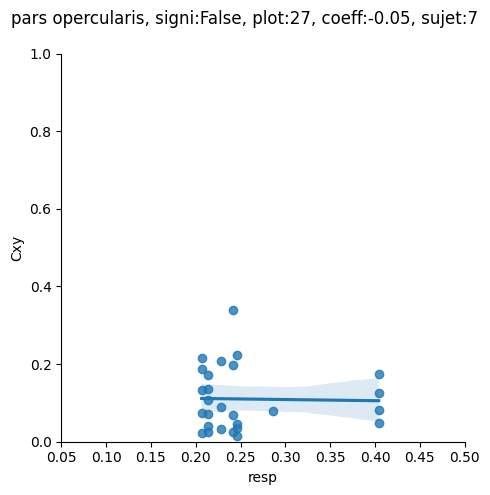

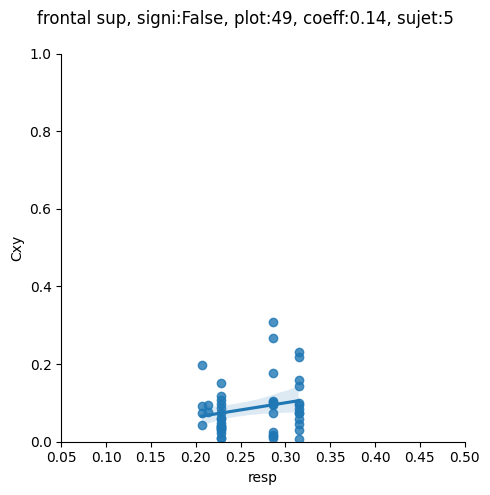

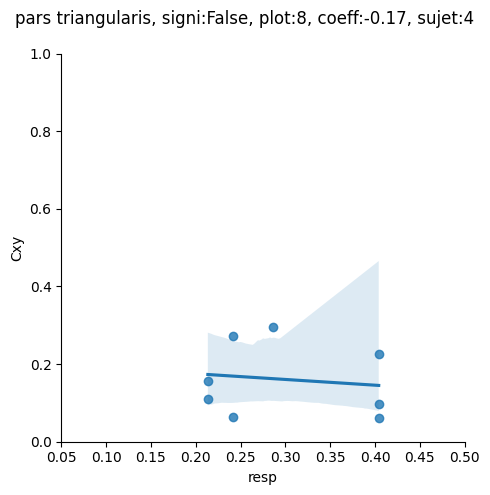

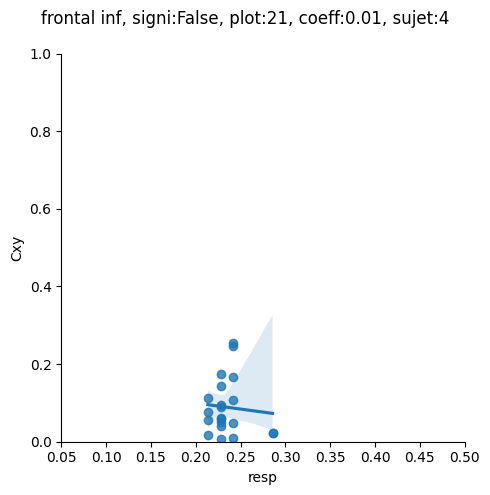

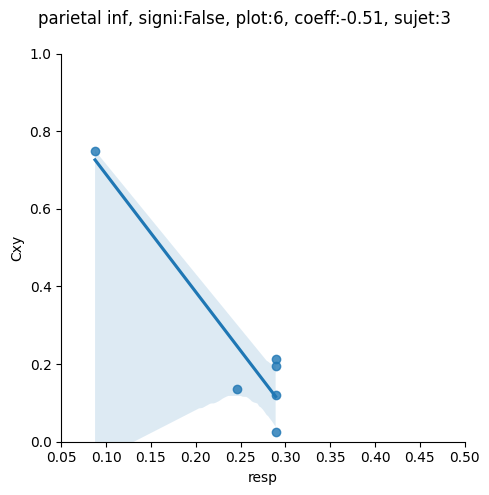

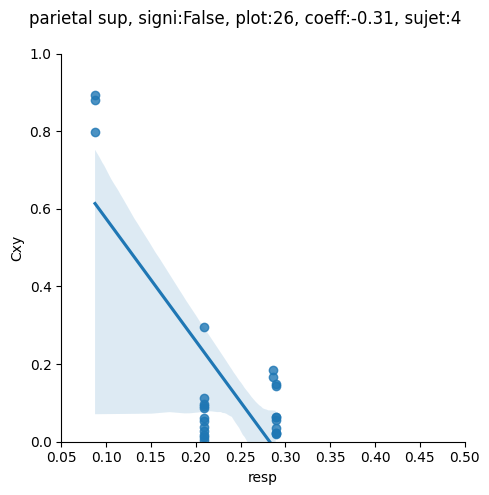

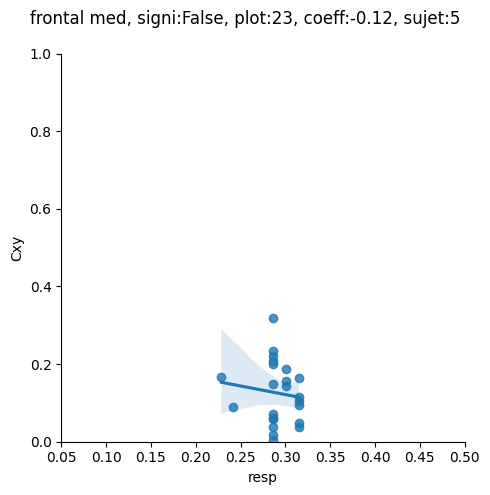

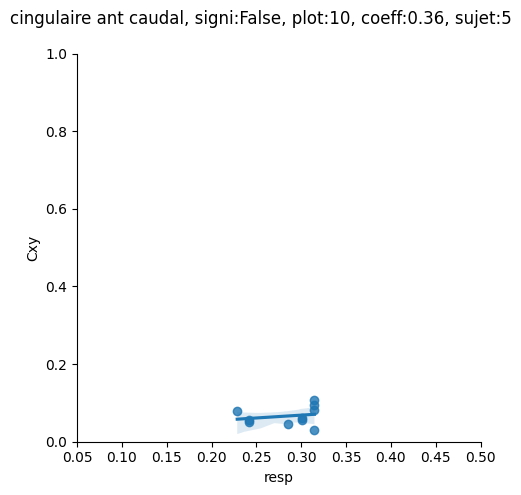

In [ ]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if df_spearman.query(f"ROI == '{ROI}'")['signi'].values == True:
        continue
    
    pval = df_spearman.query(f"ROI == '{ROI}'")['signi'].values[0]
    sns.lmplot(x="resp", y="Cxy", data=df_spearman)
    _coeff = df_spearman.query(f"ROI == '{ROI}'")['rho'].values[0]
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, signi:{pval}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

### OLS allplot

In [42]:
data = {'ROI' : [], 'coeff' : [], 'intercept' : [], 'pval' : [], 'p' : []}

for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV.query(f"ROI == '{ROI}'")[['Cxy', 'resp']]

    x = _df_lmm['resp']
    y = _df_lmm['Cxy']

    x = sm.add_constant(x)

    mdl = sm.OLS(y, x).fit()
    mdl_fit = mdl.predict(x) 

    coeff = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[-1]
    intercept = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[0]
    pval = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['P>|t|'].values[-1]

    if pval < 0.05:

        p = 1

    else:

        p = 0

    data['ROI'].append(ROI)
    data['coeff'].append(coeff)
    data['intercept'].append(intercept)
    data['pval'].append(pval)
    data['p'].append(p)

    
    # fig, axs = plt.subplots(ncols=2, figsize=(10,5))

    # sns.histplot(mdl_fit.resid, ax=axs[0])
    # sm.qqplot(mdl_fit.resid, dist=stats.norm, line='s', ax=axs[1])

    # plt.suptitle(f"{ROI}")

    # fig.savefig(os.path.join(path_results, 'allplot', 'allcond', 'PSD_Coh', 'stats', f'{ROI}_qqplot_distrib_LMM_FR_CV_Cxy.png'))

    # plt.close()

    # plt.show()


df_lmm = pd.DataFrame(data)

/tmp/ipykernel_218168/2571507309.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  coeff = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[-1]
/tmp/ipykernel_218168/2571507309.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  intercept = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['coef'].values[0]
/tmp/ipykernel_218168/2571507309.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pval = pd.read_html(mdl.summary().tables[1].as_html(), header=0, index_col=0)[0]['P>|t|'].values[-1]
/tmp/ipykernel_218168/2571507309.py:15: FutureWarning: Passin

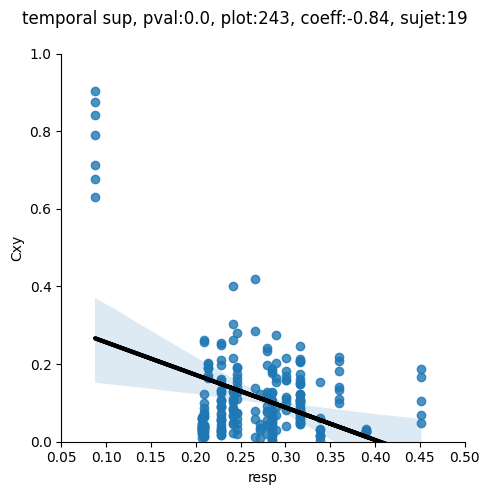

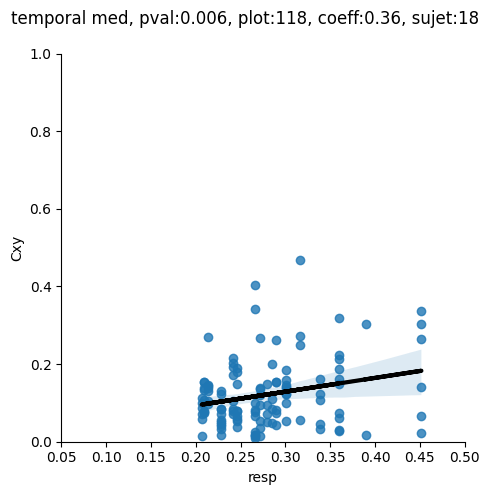

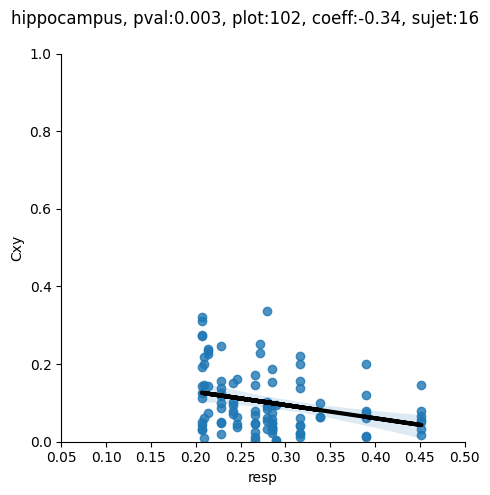

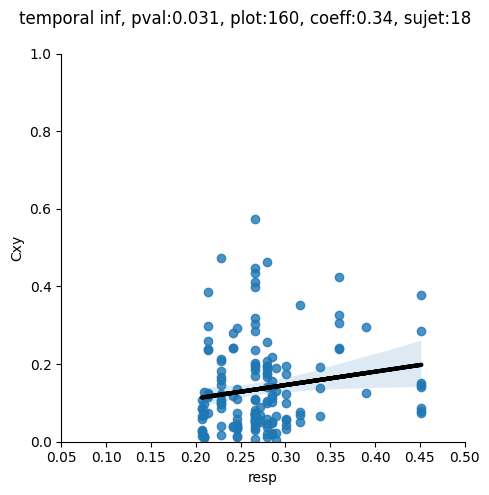

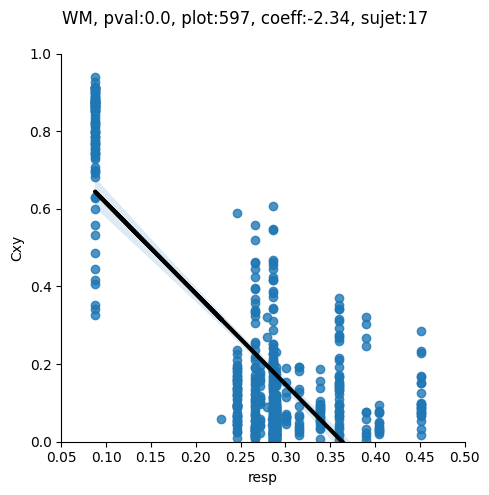

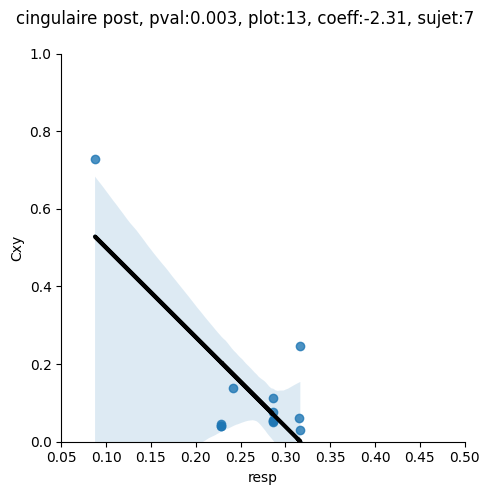

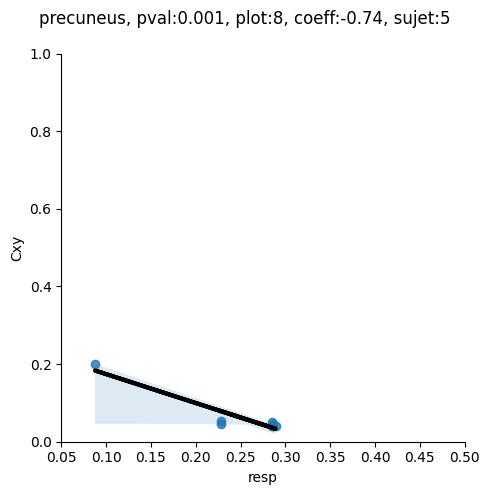

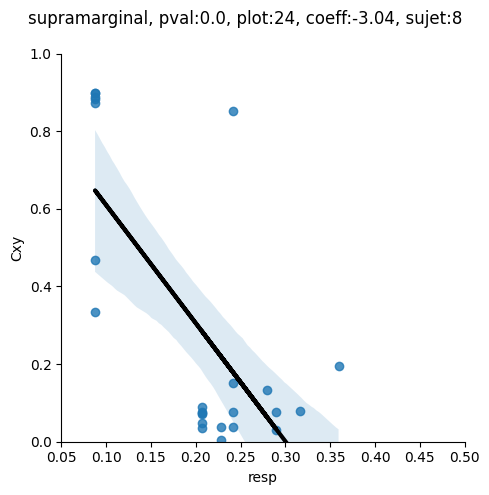

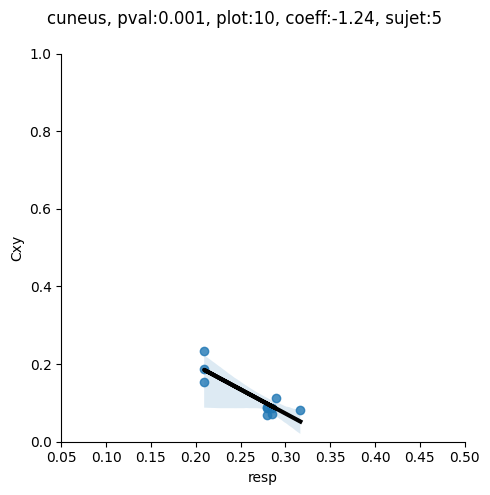

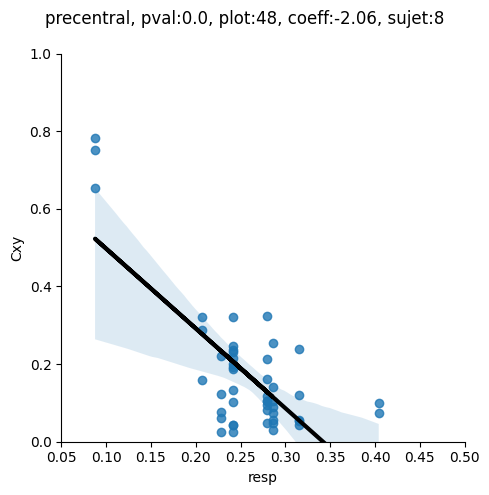

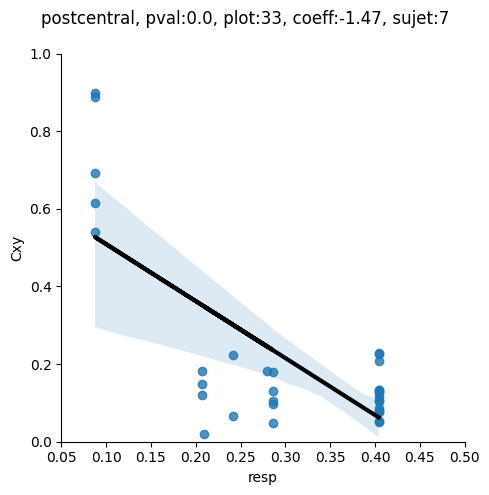

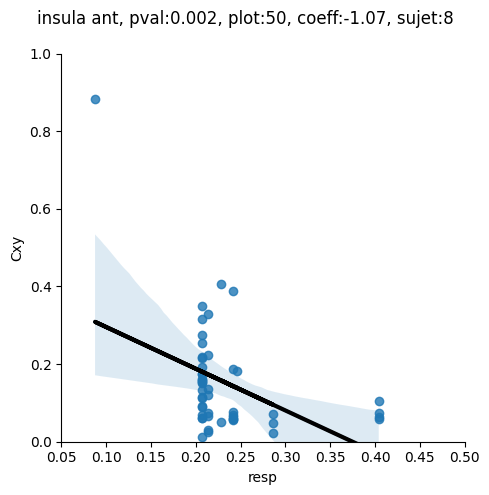

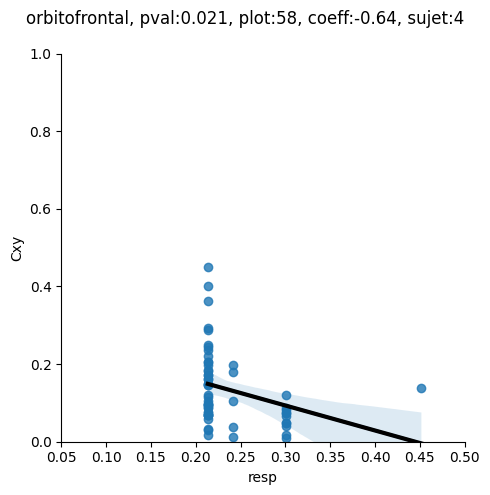

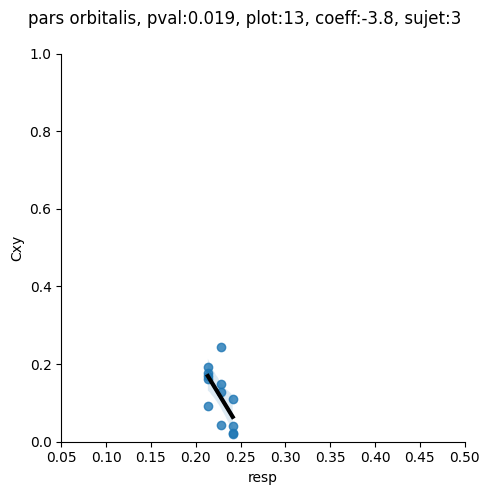

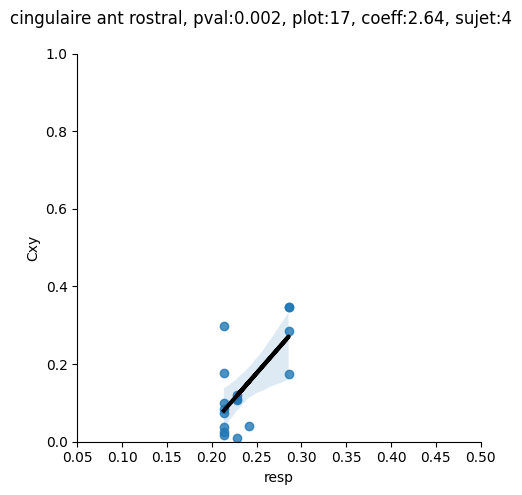

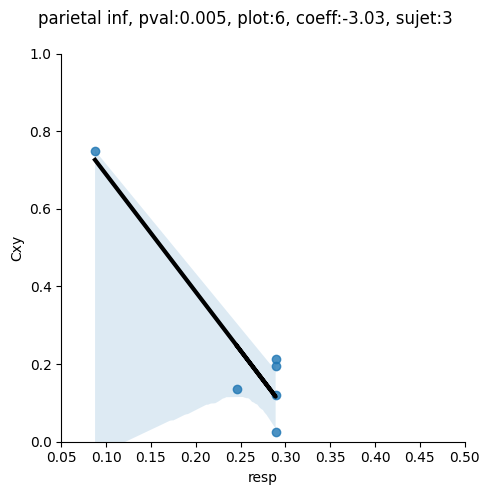

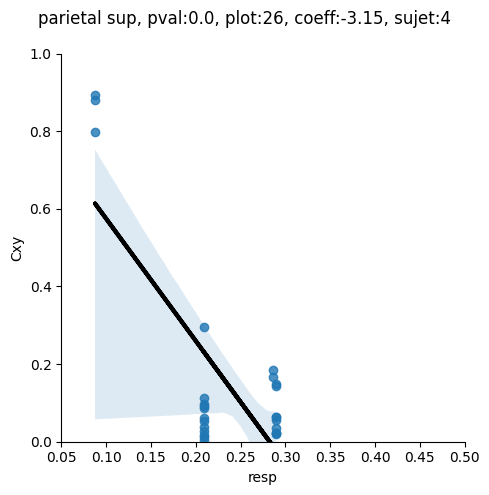

In [43]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if df_lmm.query(f"ROI == '{ROI}'")['p'].values != 1:
        continue
    
    pval = df_lmm.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(x="resp", y="Cxy", data=_df_lmm)
    _coeff = df_lmm.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_lmm['resp'].values*_coeff + df_lmm.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    plt.plot(_df_lmm['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, pval:{pval}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

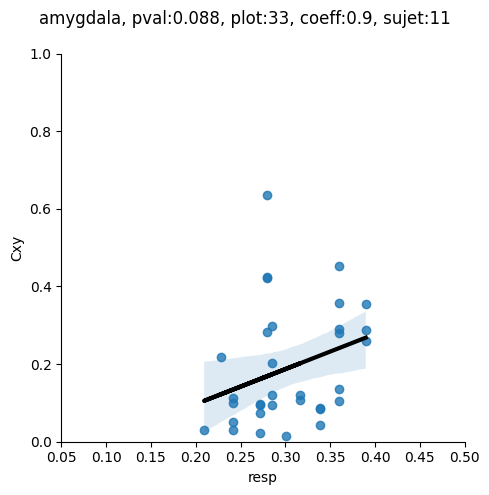

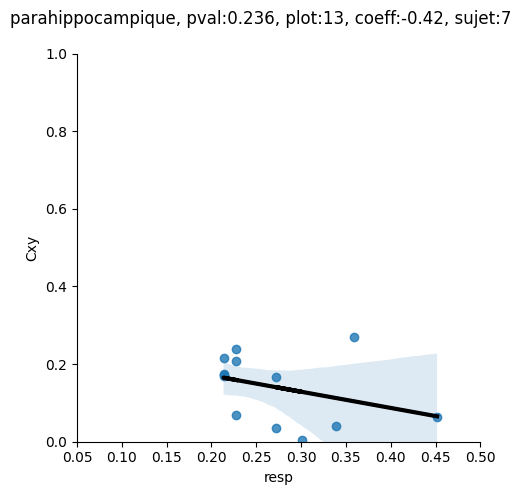

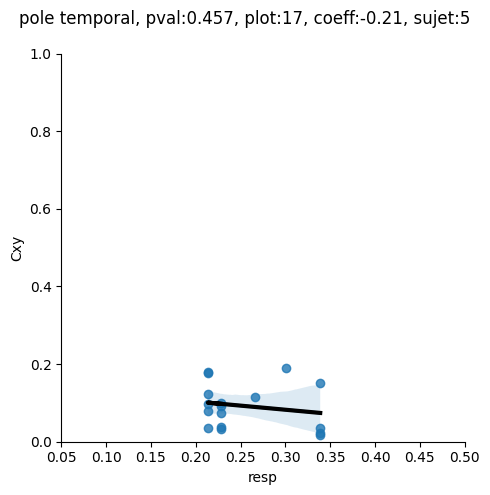

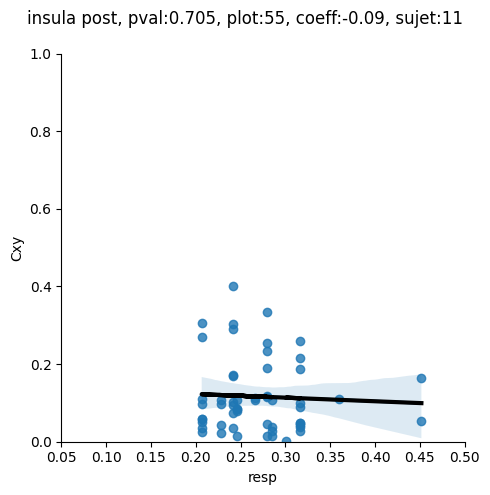

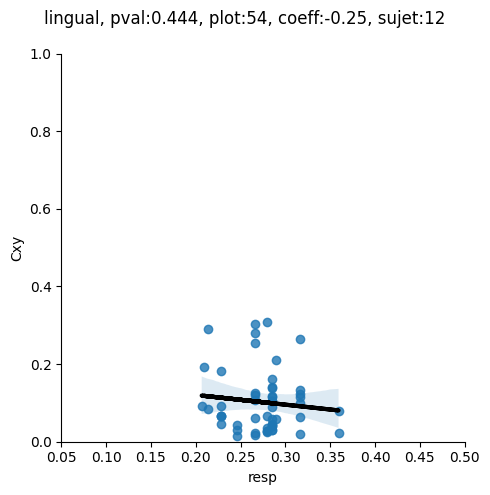

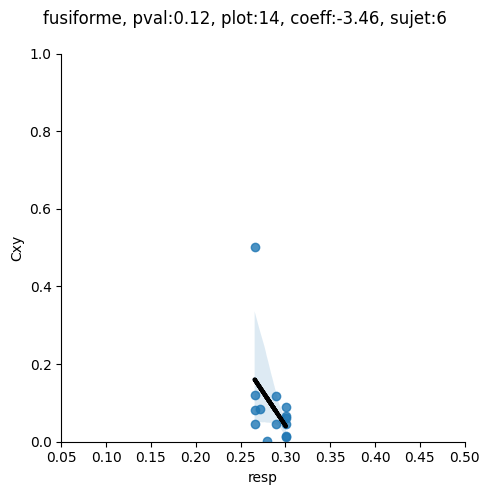

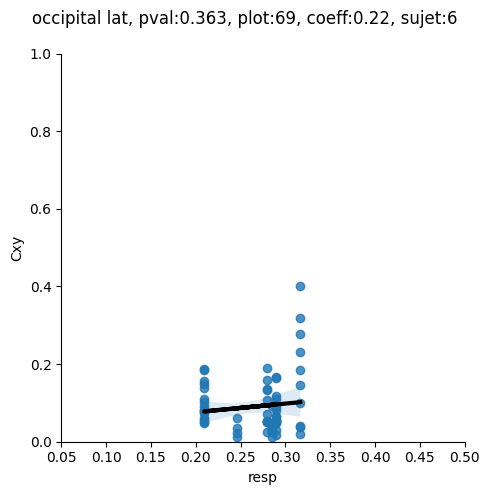

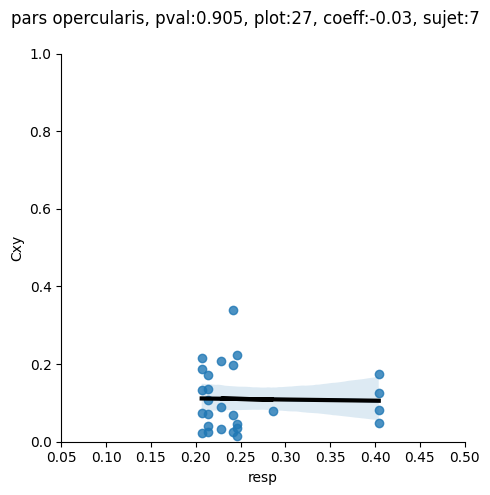

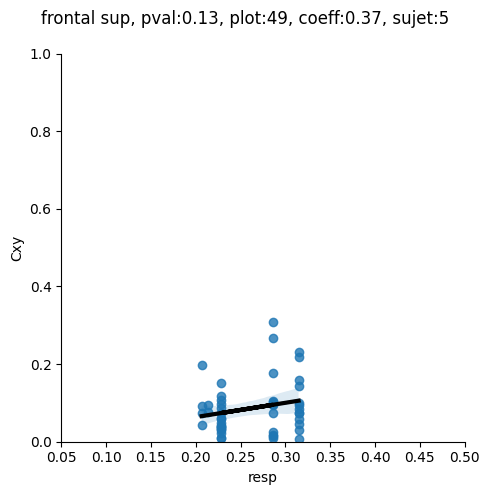

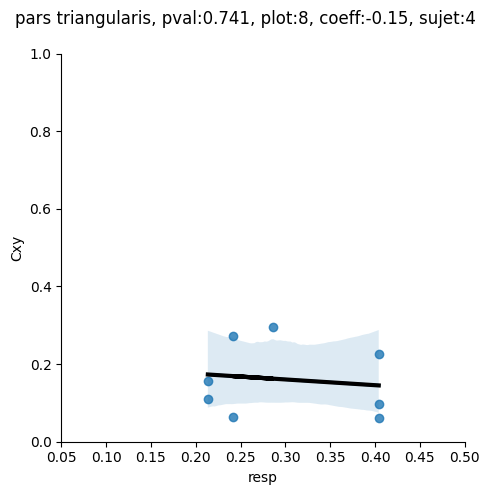

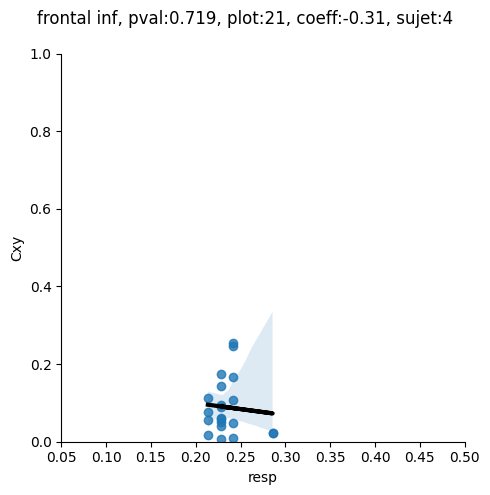

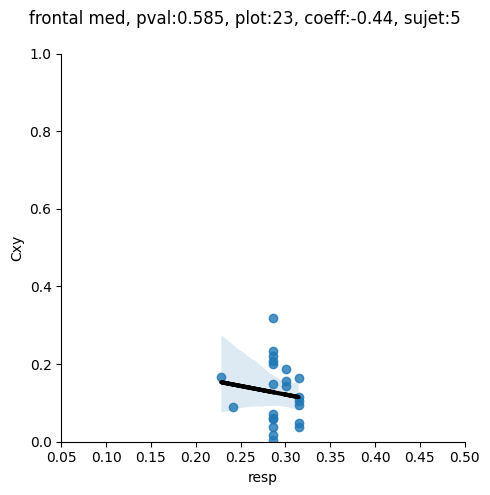

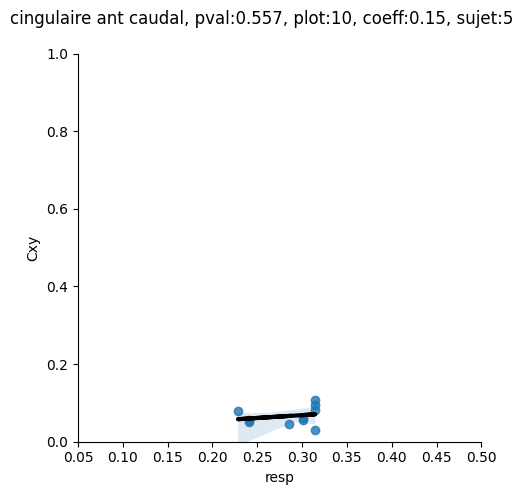

In [44]:
for ROI in ROI_list_FR_CV_filt:

    _df_lmm = df_Cxy_FR_CV.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]

    if df_lmm.query(f"ROI == '{ROI}'")['p'].values == 1:
        continue
    
    pval = df_lmm.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(x="resp", y="Cxy", data=_df_lmm)
    _coeff = df_lmm.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_lmm['resp'].values*_coeff + df_lmm.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05,0.5)
    plt.plot(_df_lmm['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, pval:{pval}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

## ALL CONDITIONS

### PROPORTION

In [116]:
data_df = {'cond' : [], 'ROI' : [], 'Cxy_p' : []}

for cond in conditions:

    for ROI in ROI_list_allcond_filt:
        
        signi = (df_Cxy_allcond_filt.query(f"cond == '{cond}' and ROI == '{ROI}'")['Cxy'] > df_Cxy_allcond_filt.query(f"cond == '{cond}' and ROI == '{ROI}'")['Cxy_surr']).sum()
        prop_Cxy = signi/df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
        
        data_df['cond'].append(cond)
        data_df['ROI'].append(ROI)
        data_df['Cxy_p'].append(prop_Cxy)

df_Cxy_p = pd.DataFrame(data_df) 

Text(0.5, 1.0, 'Cxy_p')

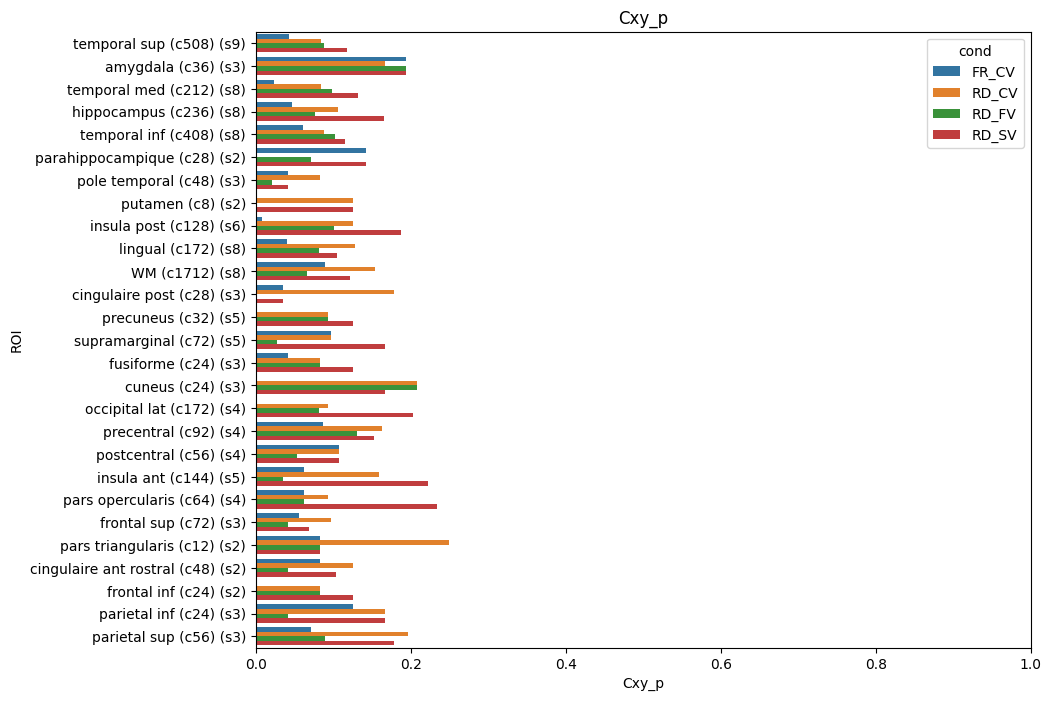

In [117]:
df_plot = df_Cxy_p

fig, ax = plt.subplots(figsize = (10,8))
g = sns.barplot(data=df_plot , x='Cxy_p', y='ROI', hue='cond', ax=ax)

ROI_labels = []

for ROI_i, ROI in enumerate(ROI_list_allcond_filt):

    _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f'{ROI} (c{_count_plot}) (s{_count_sujet})')

g.set_yticks(range(len(ROI_labels)))
g.set_yticklabels(ROI_labels)
ax.tick_params(axis='y')
ax.set_xlim(0,1)

ax.set_title('Cxy_p')

<Axes: xlabel='cond', ylabel='Cxy_p'>

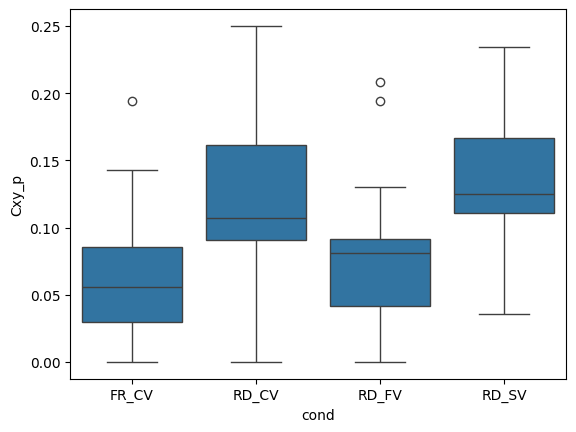

In [118]:
sns.boxplot(data=df_Cxy_p, x="cond", y="Cxy_p")

In [119]:
df_Cxy_allcond_diff = pd.melt(pd.DataFrame({'ROI' : df_Cxy_p.query(f"cond == 'RD_CV'")['ROI'].values, 'RD_CV' : df_Cxy_p.query(f"cond == 'RD_CV'")['Cxy_p'].values - df_Cxy_p.query(f"cond == 'FR_CV'")['Cxy_p'].values,
'RD_SV' : df_Cxy_p.query(f"cond == 'RD_SV'")['Cxy_p'].values - df_Cxy_p.query(f"cond == 'FR_CV'")['Cxy_p'].values,
'RD_FV' : df_Cxy_p.query(f"cond == 'RD_FV'")['Cxy_p'].values - df_Cxy_p.query(f"cond == 'FR_CV'")['Cxy_p'].values}),           

id_vars='ROI', 
value_vars=['RD_CV', 'RD_SV', 'RD_FV'], 
var_name='cond', 
value_name='Cxy_p')

Text(0.5, 1.0, 'Cxy_p')

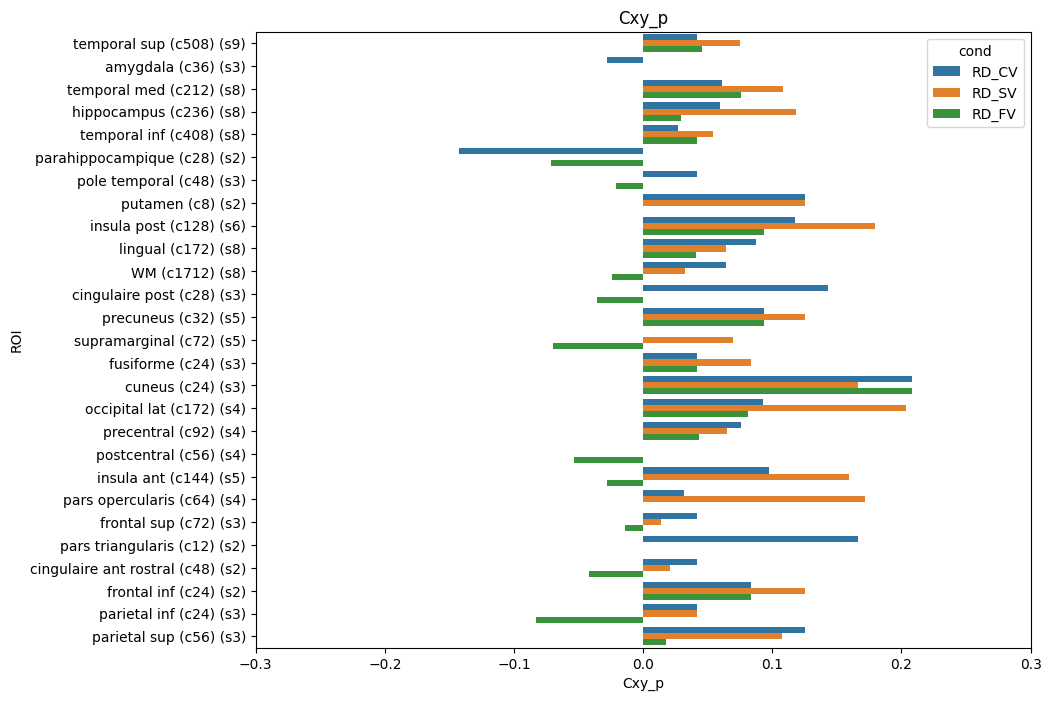

In [120]:
df_plot = df_Cxy_allcond_diff

fig, ax = plt.subplots(figsize = (10,8))
g = sns.barplot(data=df_plot , x='Cxy_p', y='ROI', hue='cond', ax=ax)

ROI_labels = []

for ROI_i, ROI in enumerate(ROI_list_allcond_filt):

    _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f'{ROI} (c{_count_plot}) (s{_count_sujet})')

g.set_yticks(range(len(ROI_labels)))
g.set_yticklabels(ROI_labels)
ax.tick_params(axis='y')
ax.set_xlim(-0.3,0.3)

ax.set_title('Cxy_p')

<Axes: xlabel='cond', ylabel='Cxy_p'>

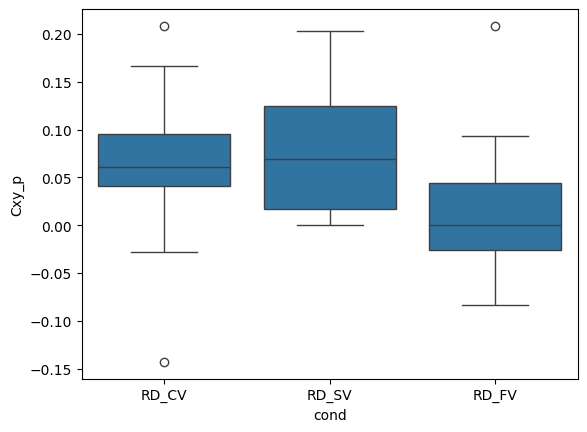

In [121]:
sns.boxplot(data=df_Cxy_allcond_diff, x="cond", y="Cxy_p")

<Axes: xlabel='cond', ylabel='Cxy_p'>

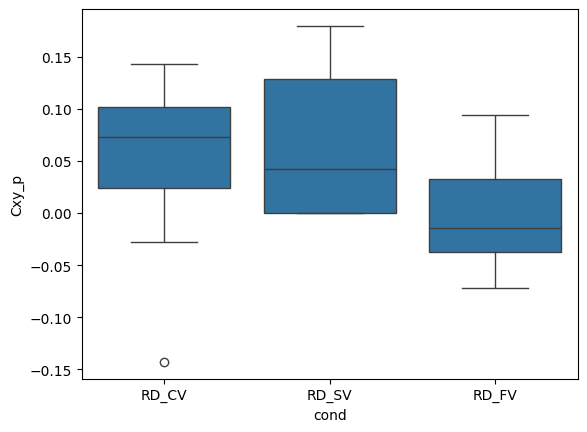

In [122]:
_ROI_list_short = ['amygdala', 'hippocampus',
       'parahippocampique',
       'insula post', 'lingual', 'cingulaire post', 
       'insula ant',
       'cingulaire ant rostral',
       'cingulaire ant caudal']
df_plot = df_Cxy_allcond_diff.query(f"ROI in {_ROI_list_short}")
sns.boxplot(data=df_plot, x="cond", y="Cxy_p")

### LMM Cxy

In [128]:
os.chdir(os.path.join(path_results, 'allplot', 'LMM', 'Cxy', 'df_lmm'))
df_lmm_allcond = pd.DataFrame()

for ROI in ROI_list_allcond_filt:

    _df = pd.read_excel(f'lmm_{ROI}_res.xlsx')
    _df['ROI'] = [ROI] * 2
    df_lmm_allcond = pd.concat([df_lmm_allcond, _df])

In [129]:
data = {'ROI' : [], 'coeff' : [], 'intercept' : [], 'pval' : [], 'p' : []}

for ROI in ROI_list_allcond_filt:

    coeff = df_lmm_allcond.query(f"ROI == '{ROI}' and term == 'resp'")['estimate'].values[0]
    pval = df_lmm_allcond.query(f"ROI == '{ROI}' and term == 'resp'")['p.value'].values[0]
    intercept = df_lmm_allcond.query(f"ROI == '{ROI}' and term == '(Intercept)'")['estimate'].values[0]

    if pval < 0.05:

        p = 1

    else:

        p = 0

    data['ROI'].append(ROI)
    data['coeff'].append(coeff)
    data['intercept'].append(intercept)
    data['pval'].append(pval)
    data['p'].append(p)


df_lmm_allcond_summary = pd.DataFrame(data)
df_lmm_allcond_summary

,ROI,coeff,intercept,pval,p
0,temporal sup,-0.524540,-1.676334,7.488237e-02,0
1,amygdala,1.375100,-1.878456,7.410819e-02,0
2,temporal med,-0.248530,-1.918275,5.842385e-01,0
3,hippocampus,-0.955732,-1.689432,2.558249e-02,1
4,temporal inf,-0.832329,-1.731789,1.592322e-02,1
5,parahippocampique,-0.987916,-1.721199,2.243129e-01,0
6,pole temporal,0.188943,-2.361342,8.307829e-01,0
7,putamen,0.302997,-1.856955,9.114855e-01,0
8,insula post,-1.335684,-1.207199,3.029050e-02,1
9,lingual,-0.634335,-1.640349,2.641997e-01,0


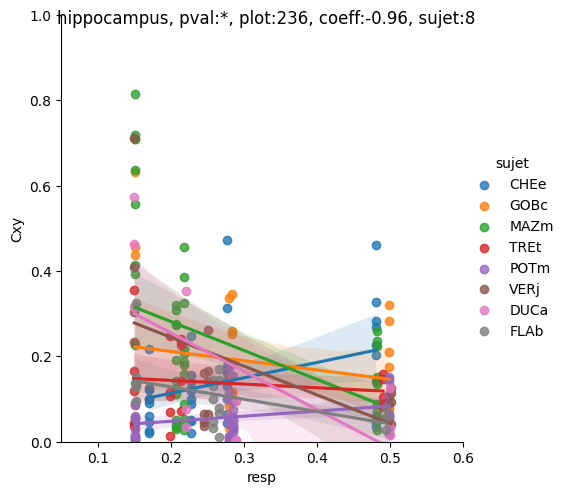

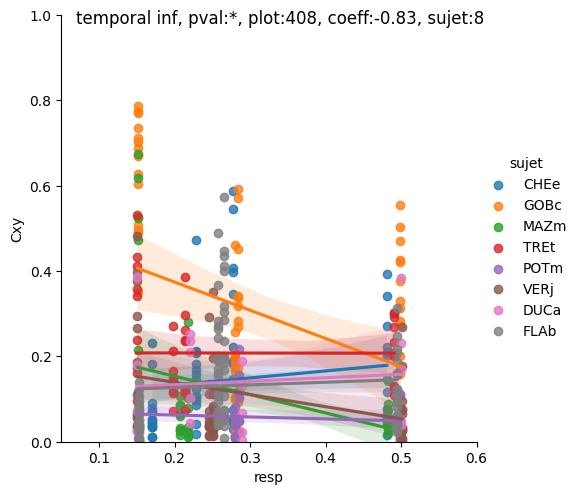

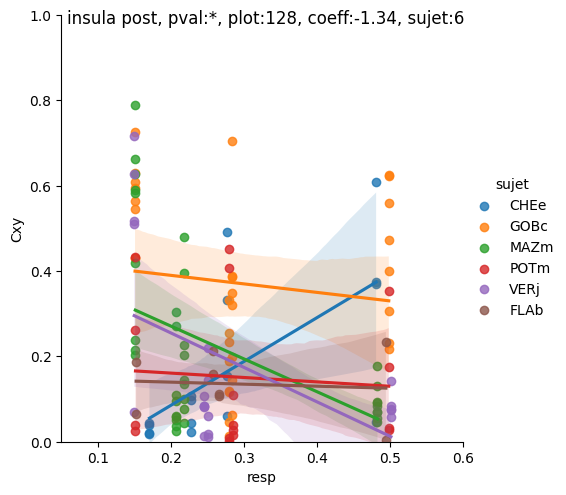

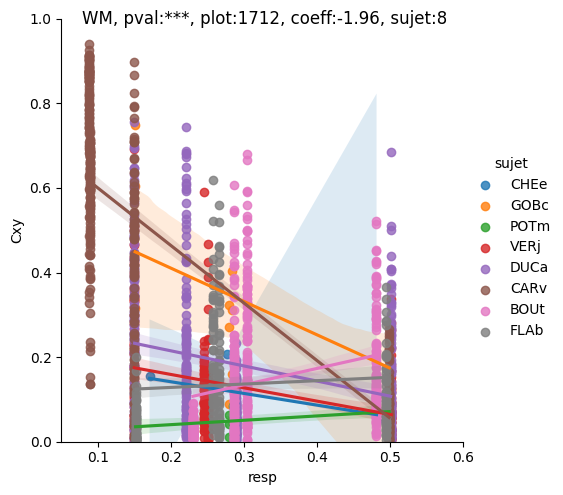

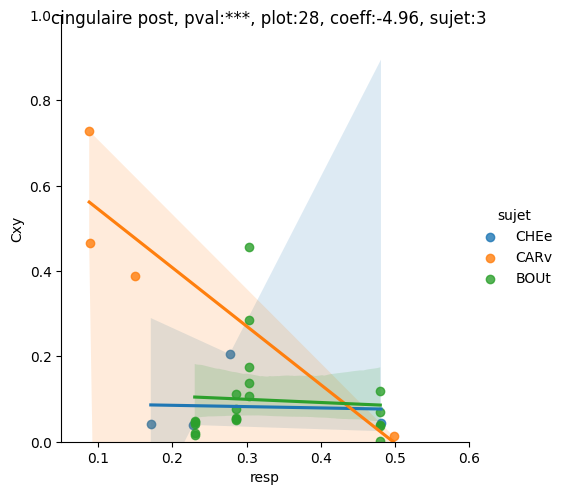

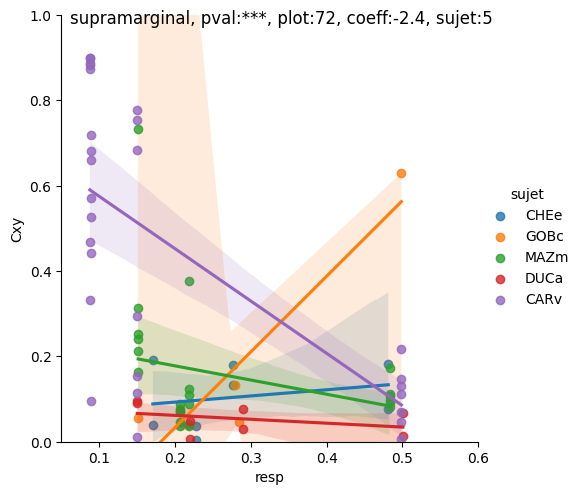

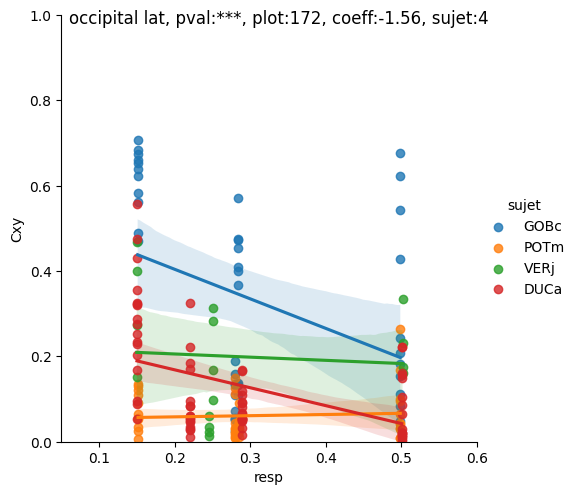

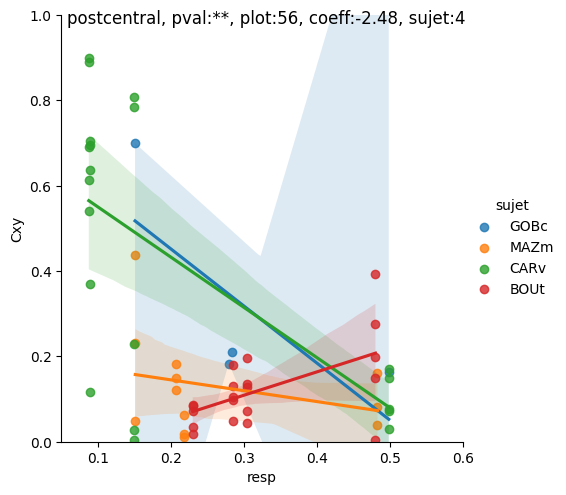

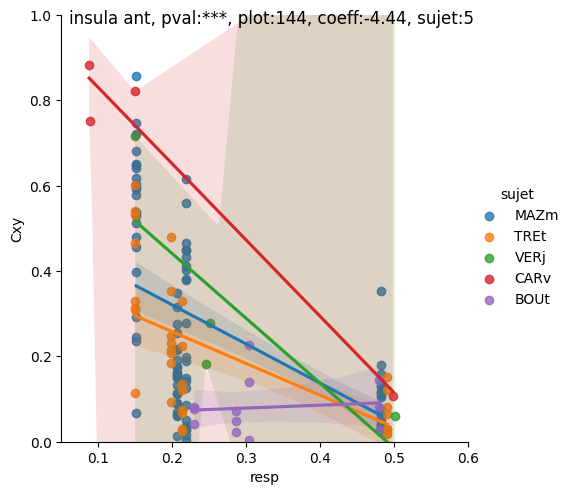

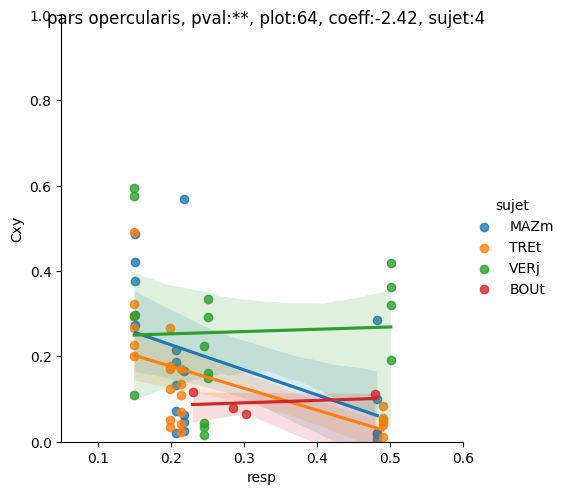

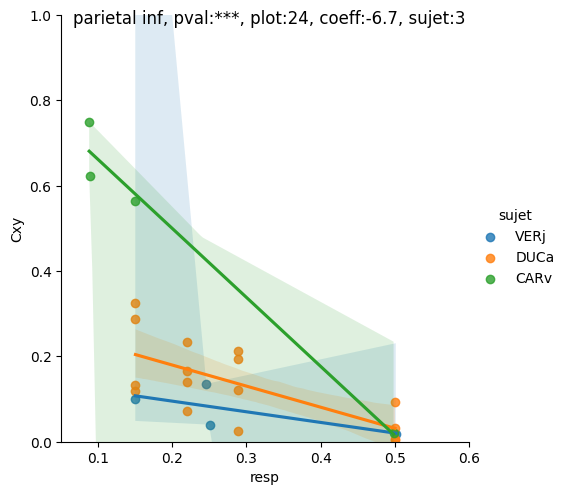

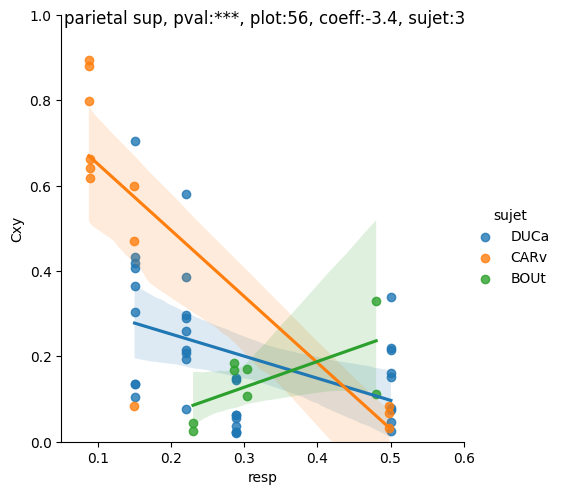

In [130]:
for ROI in ROI_list_allcond_filt:

    if df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['p'].values != 1:

        continue 

    _df_Cxy_allcond_filt = df_Cxy_allcond_filt.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]
    
    pval = df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(x="resp", y="Cxy", hue='sujet', data=_df_Cxy_allcond_filt)
    _coeff = df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_Cxy_allcond_filt['resp'].values*_coeff + df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05, 0.6)
    plt.plot(_df_Cxy_allcond_filt['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, pval:{get_pval(pval)}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
        

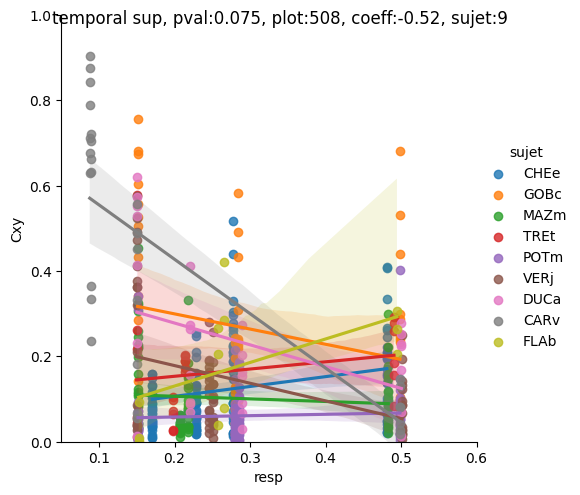

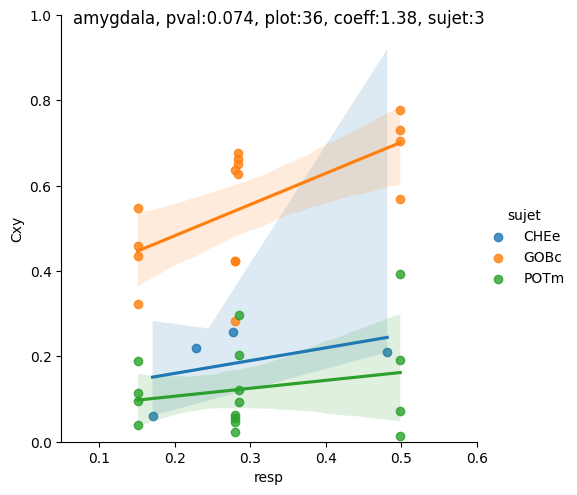

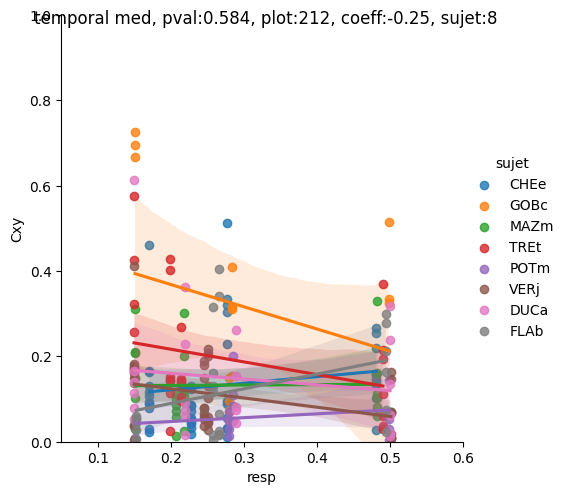

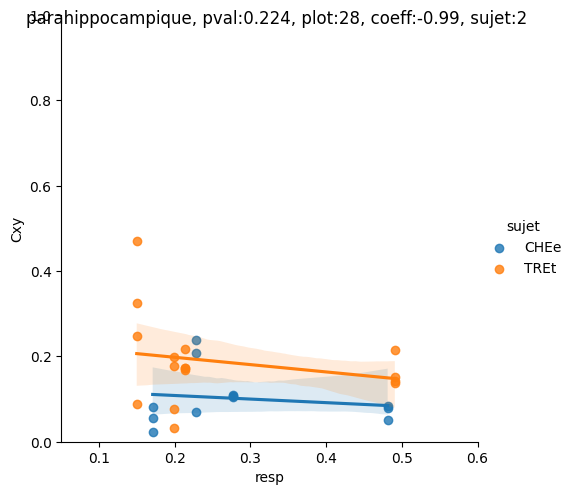

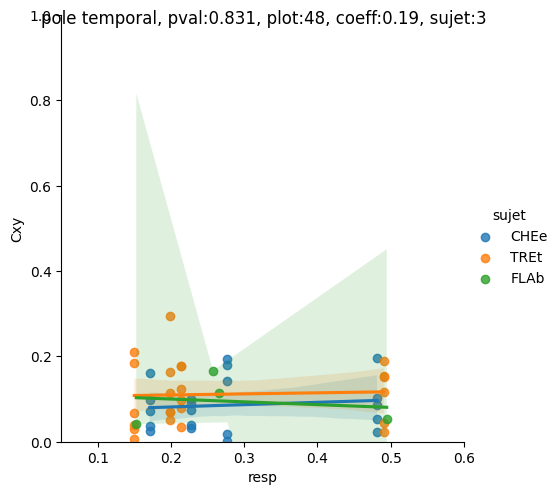

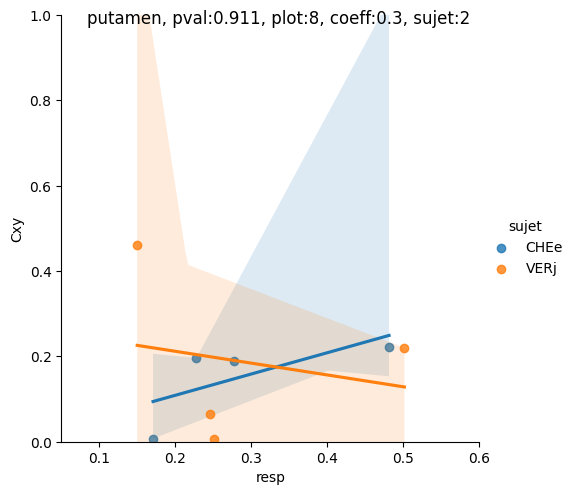

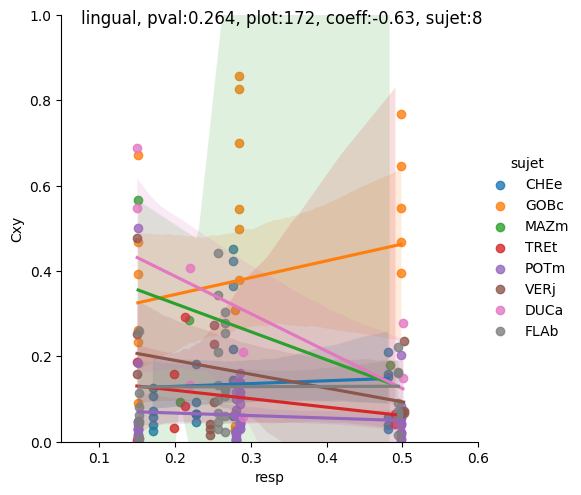

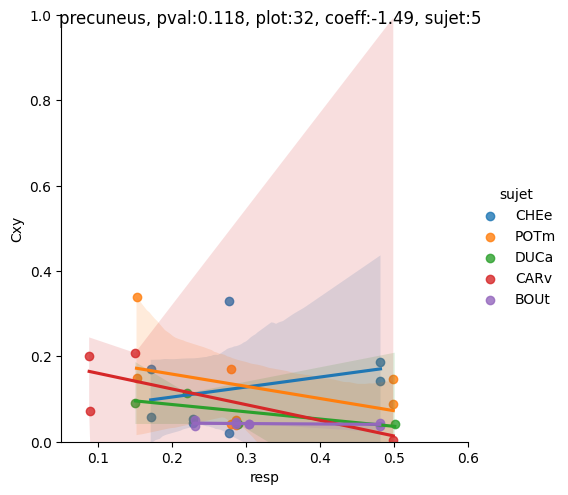

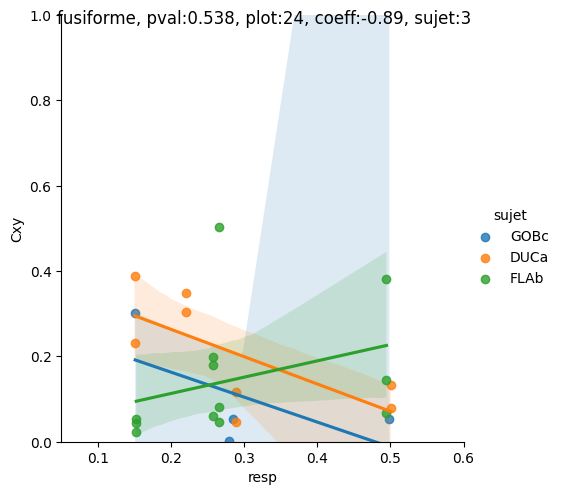

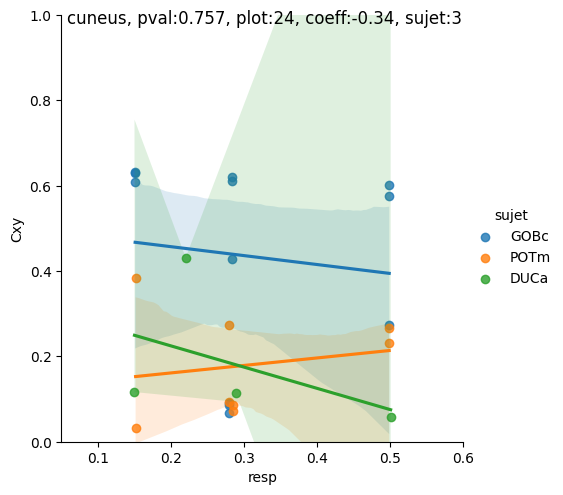

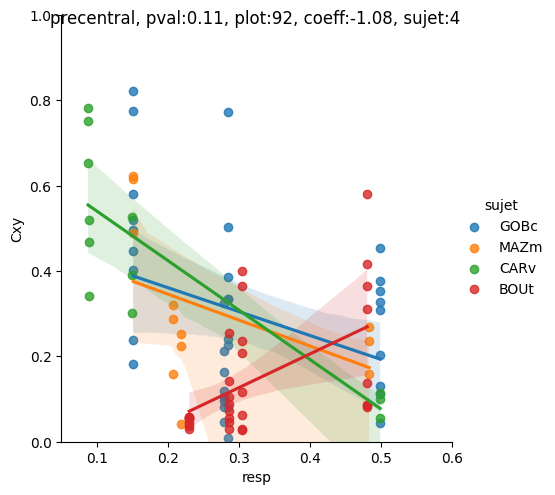

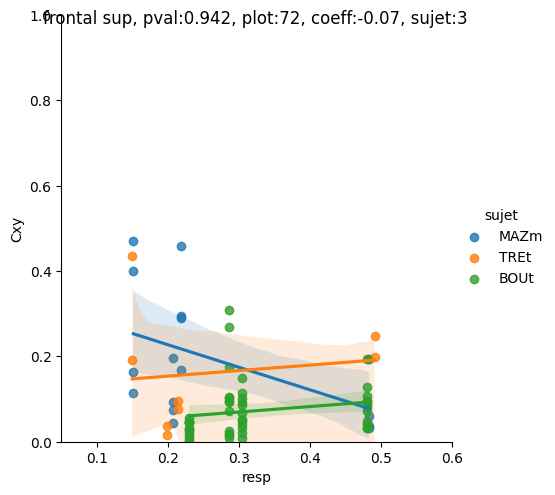

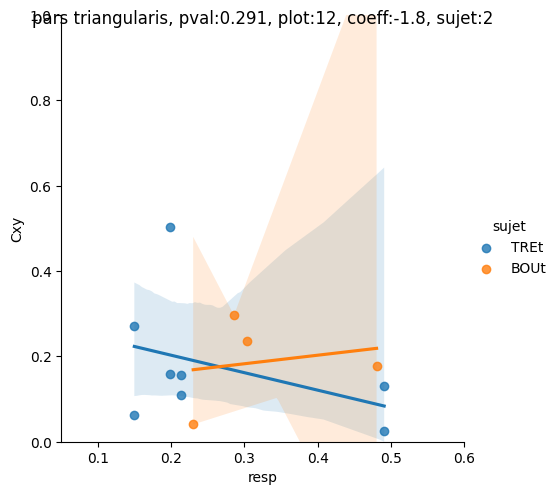

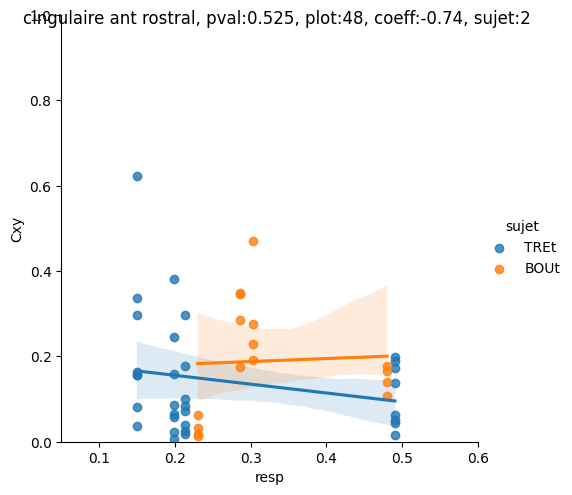

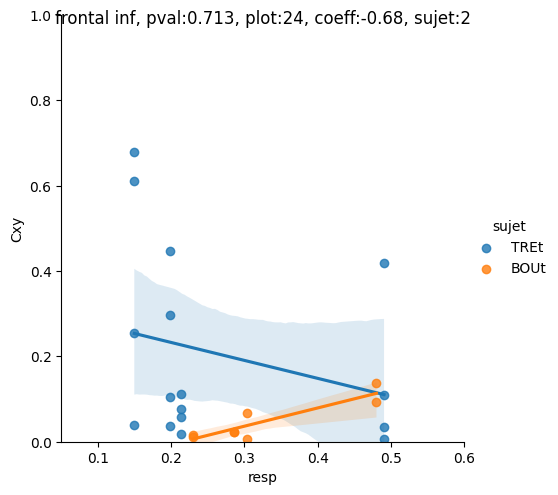

In [131]:
for ROI in ROI_list_allcond_filt:

    if df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['p'].values == 1:

        continue 

    _df_Cxy_allcond_filt = df_Cxy_allcond_filt.query(f"ROI == '{ROI}'")[['sujet', 'Cxy', 'resp']]
    
    pval = df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['pval'].values[0]
    sns.lmplot(x="resp", y="Cxy", hue='sujet', data=_df_Cxy_allcond_filt)
    _coeff = df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['coeff'].values[0]
    _ROI_mdl = _df_Cxy_allcond_filt['resp'].values*_coeff + df_lmm_allcond_summary.query(f"ROI == '{ROI}'")['intercept'].values
    plt.ylim(0,1)
    plt.xlim(0.05, 0.6)
    plt.plot(_df_Cxy_allcond_filt['resp'].values, _ROI_mdl, color='k', linewidth=3)
    _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, pval:{get_pval(np.round(pval,3))}, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")

# Pxx

## FR_CV

### PHASE LMM

In [28]:
os.chdir(os.path.join(path_results, 'allplot', 'LMM', 'Pxx', 'df_lmm'))
df_lmm_FR_CV = pd.DataFrame()

for ROI in ROI_list_allcond_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        _df = pd.read_excel(f'lmm_{ROI}_{band}_res_FR_CV.xlsx')
        _df['ROI'] = [ROI] * 2
        _df['band'] = [band] * 2
        df_lmm_FR_CV = pd.concat([df_lmm_FR_CV, _df])

In [29]:
data = {'ROI' : [], 'band' : [], 'estimate' : [], 'pval' : [], 'p' : []}

for ROI in ROI_list_allcond_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        df = df_lmm_FR_CV.query(f"ROI == '{ROI}' and band == '{band}'")
        _estimate = df.query("term == 'phaseinspi'")['estimate'].iloc[0]
        pval = df.query("term == 'phaseinspi'")['p.value'].iloc[0]
        if pval < 0.05:
            p = 1
        else:
            p = 0

        data['ROI'].append(ROI)
        data['band'].append(band)
        data['estimate'].append(_estimate)
        data['pval'].append(pval)
        data['p'].append(p)

df_phase_FR_CV_pval = pd.DataFrame(data)
df_phase_FR_CV_pval


,ROI,band,estimate,pval,p
0,temporal sup,theta,-0.004045,2.676166e-01,0
1,temporal sup,alpha,-0.004750,2.517953e-01,0
2,temporal sup,beta,-0.004686,1.529979e-02,1
3,temporal sup,gamma,-0.001470,2.053609e-01,0
4,amygdala,theta,0.021942,1.400469e-03,1
...,...,...,...,...,...
103,parietal inf,gamma,0.001331,6.228799e-01,0
104,parietal sup,theta,-0.033769,5.206311e-04,1
105,parietal sup,alpha,-0.069563,5.984053e-09,1
106,parietal sup,beta,-0.038735,8.767262e-07,1


In [30]:
ROI_labels = []

for ROI in df_phase_FR_CV_pval.query("p == 1")['ROI'].unique():
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    ROI_labels.append(f"{ROI} (c{_count_plot}) (s{_count_sujet})")


/tmp/ipykernel_5954/90455578.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(data=df_plot.query("p == 1"), x='ROI', y='estimate', hue='band', join=False)
/tmp/ipykernel_5954/90455578.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(ROI_labels)


Text(0.5, 0.98, 'FR_CV')

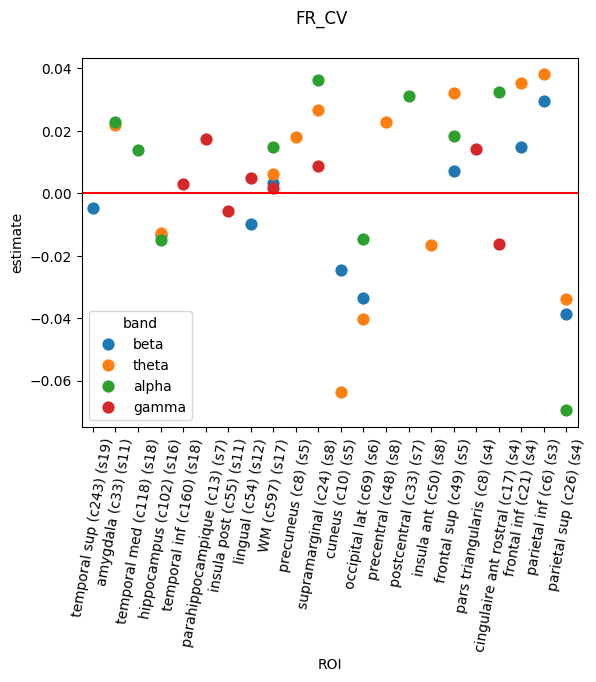

In [31]:
df_plot = df_phase_FR_CV_pval
g = sns.pointplot(data=df_plot.query("p == 1"), x='ROI', y='estimate', hue='band', join=False)
g.axhline(0, color='r')
g.set_xticklabels(ROI_labels)
plt.xticks(rotation=80)
plt.suptitle('FR_CV')

/tmp/ipykernel_5954/195286412.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(data=df_plot.query("p == 1"), x='estimate', y='ROI', hue='band', join=False)
/tmp/ipykernel_5954/195286412.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(ROI_labels)


Text(0.5, 0.98, 'FR_CV')

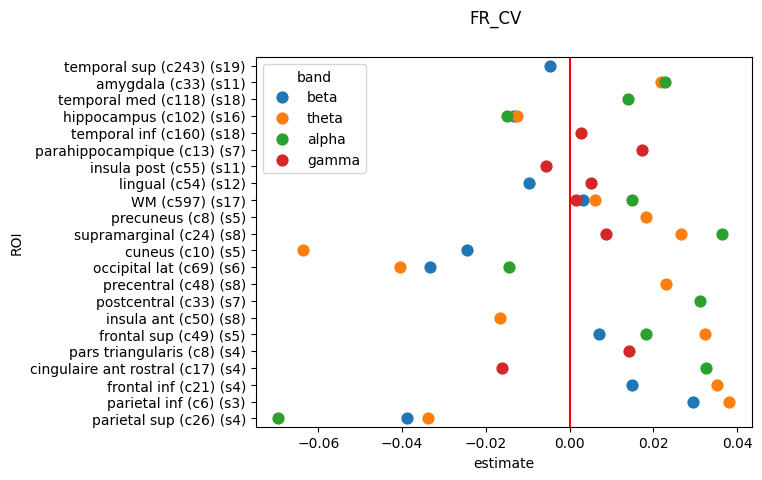

In [32]:
df_plot = df_phase_FR_CV_pval
g = sns.pointplot(data=df_plot.query("p == 1"), x='estimate', y='ROI', hue='band', join=False)
g.axvline(0, color='r')
g.set_yticklabels(ROI_labels)
plt.suptitle('FR_CV')

### Spearman allplot

In [41]:
def spearman_permutation_test(x, y, n_perm, percentile_thresh_list):

    rho_obs, _ = scipy.stats.spearmanr(x, y)

    null_dist = np.zeros(n_perm)
    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        null_dist[i], _ = scipy.stats.spearmanr(x, y_perm)

    signi = rho_obs > np.percentile(null_dist, percentile_thresh_list[1]) or rho_obs < np.percentile(null_dist, percentile_thresh_list[0])

    return rho_obs, signi

percentile_thresh_list = [2.5, 97.5]
n_perm_spearman = 500

data = {'ROI': [], 'band' : [], 'phase' : [], 'rho': [], 'signi': []}

for ROI in ROI_list_FR_CV_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        for phase in ['inspi', 'expi']:

            _df = df_Pxx_FR_CV_filt.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")[['Pxx', 'resp']]

            x = _df['resp'].values
            y = _df['Pxx'].values

            rho, signi = spearman_permutation_test(x, y, n_perm_spearman, percentile_thresh_list)

            data['ROI'].append(ROI)
            data['band'].append(band)
            data['phase'].append(phase)
            data['rho'].append(rho)
            data['signi'].append(signi)

# Build dataframe
df_spearman = pd.DataFrame(data)


/tmp/ipykernel_5954/1914919028.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


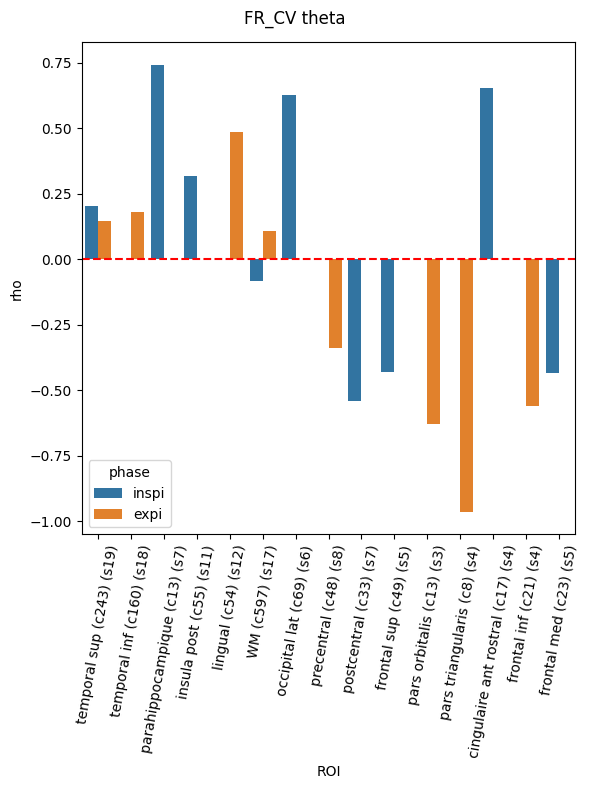

/tmp/ipykernel_5954/1914919028.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


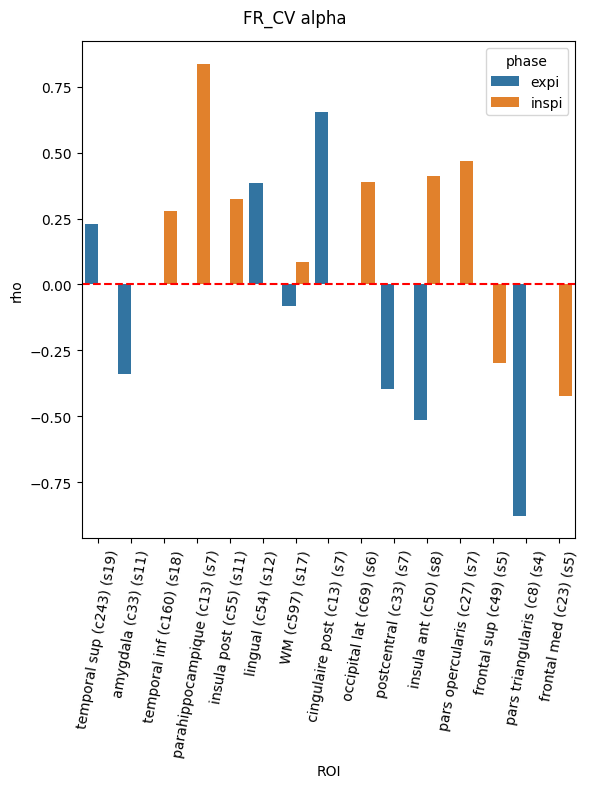

/tmp/ipykernel_5954/1914919028.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


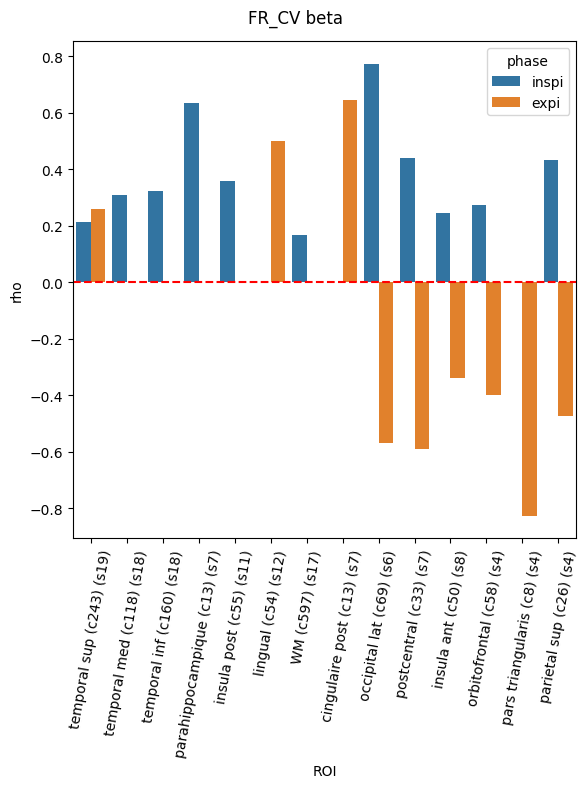

/tmp/ipykernel_5954/1914919028.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


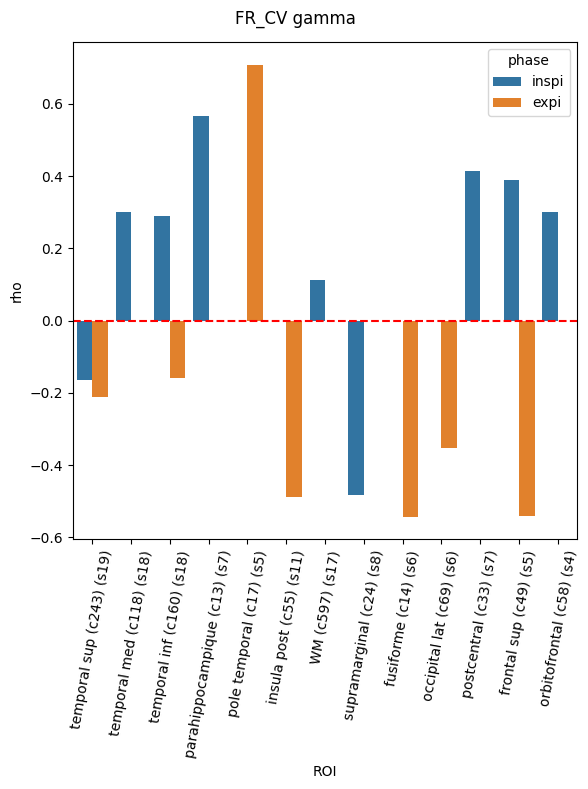

In [63]:
for band in freq_band_dict_FC_lmm['wb']:

    df_plot = df_spearman.query(f"signi == True and band == '{band}'")

    ROI_labels = []
    for ROI in df_plot['ROI'].unique():
        _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
        _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
        ROI_labels.append(f"{ROI} (c{_count_plot}) (s{_count_sujet})")

    plt.figure(figsize=(6, 8))
    ax = sns.barplot(data=df_plot, x='ROI', y='rho', hue='phase')
    ax.axhline(0, color='r', linestyle='--')
    ax.set_xticklabels(ROI_labels, rotation=80)
    plt.suptitle(f"FR_CV {band}")
    plt.tight_layout()
    plt.show()

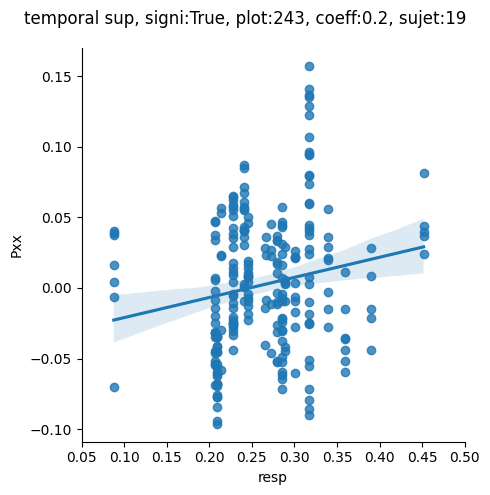

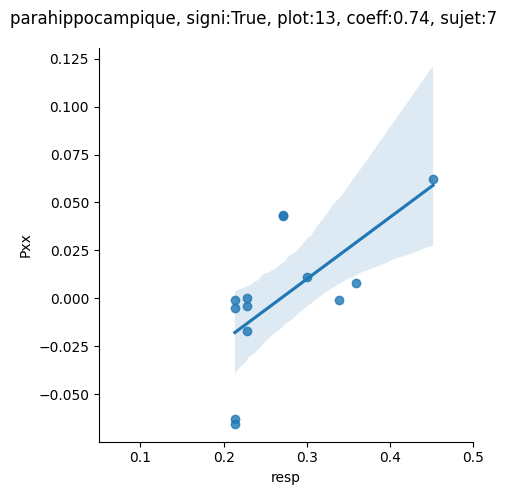

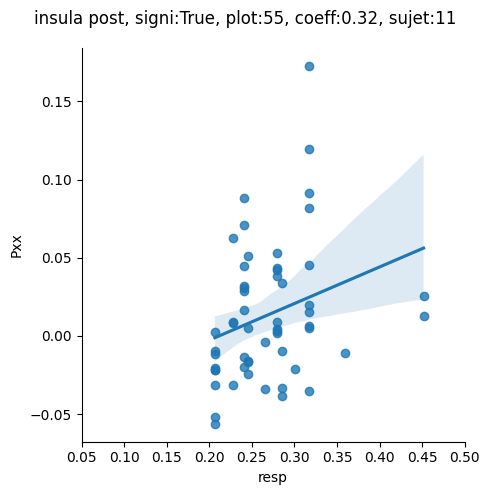

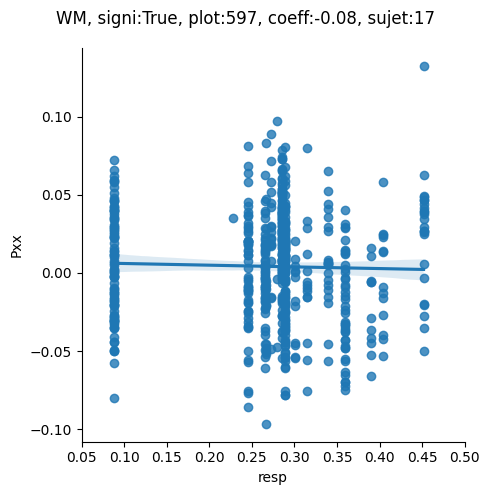

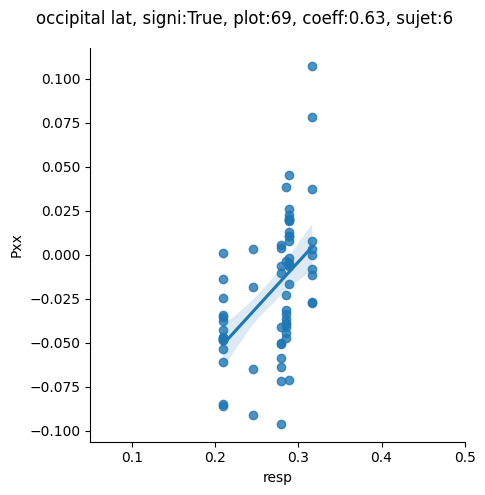

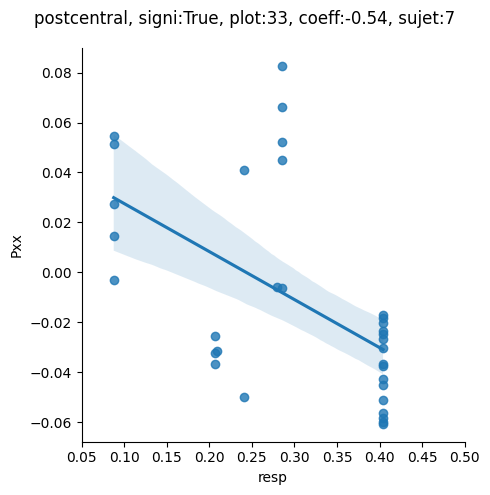

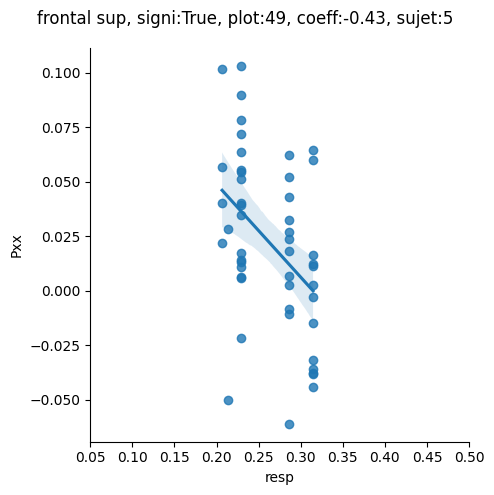

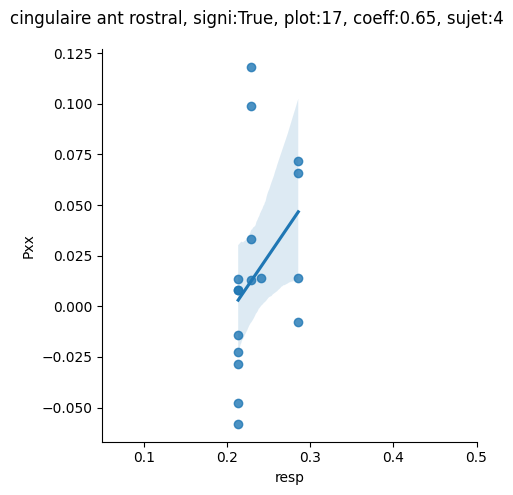

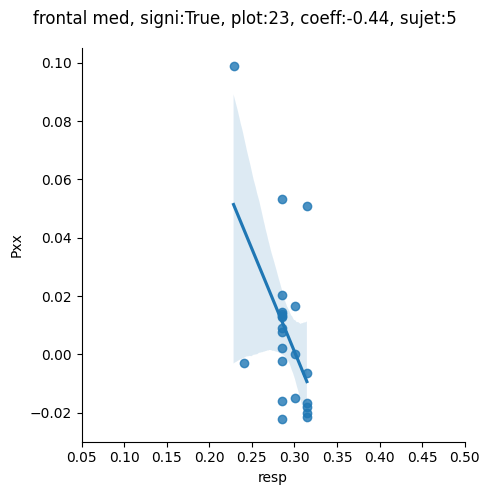

In [74]:
band = 'theta'
phase = 'inspi'

df_select_signi = df_spearman.query(f"signi == True and band == '{band}' and phase == '{phase}'")

for ROI in df_select_signi['ROI'].unique():
    
    df_plot = df_Pxx_FR_CV_filt.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")
    sns.lmplot(x="resp", y="Pxx", data=df_plot)
    _coeff = df_spearman.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")['rho'].values[0]
    plt.xlim(0.05,0.5)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, signi:True, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

## ALL CONDITIONS

### LMM

In [79]:
os.chdir(os.path.join(path_results, 'allplot', 'LMM', 'Pxx', 'df_lmm'))
df_lmm_allcond = pd.DataFrame()

for ROI in ROI_list_allcond_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        for phase in ['inspi', 'expi']:

            _df = pd.read_excel(f'lmm_{ROI}_{band}_{phase}_res_allcond.xlsx')
            _df['ROI'] = [ROI] * 4
            _df['band'] = [band] * 4
            _df['phase'] = [phase] * 4
            df_lmm_allcond = pd.concat([df_lmm_allcond, _df])

In [80]:
df_lmm_allcond

,effect,term,estimate,std.error,statistic,df,p.value,conf.low,conf.high,ROI,band,phase
0,fixed,(Intercept),0.000663,0.005435,0.121969,11.937120,0.904953,-0.011186,0.012512,temporal sup,theta,inspi
1,fixed,condRD_CV,0.001906,0.004564,0.417535,494.449804,0.676468,-0.007061,0.010872,temporal sup,theta,inspi
2,fixed,condRD_FV,0.018872,0.004564,4.135117,494.449804,0.000042,0.009905,0.027839,temporal sup,theta,inspi
3,fixed,condRD_SV,0.008639,0.004564,1.892840,494.449804,0.058963,-0.000328,0.017605,temporal sup,theta,inspi
0,fixed,(Intercept),-0.000089,0.003470,-0.025660,25.750932,0.979726,-0.007224,0.007046,temporal sup,theta,expi
...,...,...,...,...,...,...,...,...,...,...,...,...
3,fixed,condRD_SV,-0.002108,0.004515,-0.466947,52.000000,0.642488,-0.011168,0.006951,parietal sup,gamma,inspi
0,fixed,(Intercept),-0.001547,0.003853,-0.401499,9.737736,0.696722,-0.010165,0.007070,parietal sup,gamma,expi
1,fixed,condRD_CV,-0.007168,0.004772,-1.502310,50.495505,0.139245,-0.016750,0.002413,parietal sup,gamma,expi
2,fixed,condRD_FV,-0.007896,0.004772,-1.654832,50.495505,0.104162,-0.017478,0.001686,parietal sup,gamma,expi


In [86]:
data = {'ROI' : [], 'band' : [], 'phase' :[], 'cond' : [], 'coeff' : [], 'pval' : [], 'p' : []}

for ROI in ROI_list_allcond_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        for phase in ['inspi', 'expi']:

            for cond in conditions:

                if cond == 'FR_CV':
                    continue

                coeff = df_lmm_allcond.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}' and term == 'cond{cond}'")['estimate'].values[0]
                pval = df_lmm_allcond.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}' and term == 'cond{cond}'")['p.value'].values[0]

                if pval < 0.05:

                    p = 1

                else:

                    p = 0

                data['ROI'].append(ROI)
                data['band'].append(band)
                data['phase'].append(phase)
                data['cond'].append(cond)
                data['coeff'].append(coeff)
                data['pval'].append(pval)
                data['p'].append(p)

df_lmm_allcond_summary = pd.DataFrame(data)
df_lmm_allcond_summary

,ROI,band,phase,cond,coeff,pval,p
0,temporal sup,theta,inspi,RD_CV,0.001906,0.676468,0
1,temporal sup,theta,inspi,RD_FV,0.018872,0.000042,1
2,temporal sup,theta,inspi,RD_SV,0.008639,0.058963,0
3,temporal sup,theta,expi,RD_CV,-0.004763,0.265482,0
4,temporal sup,theta,expi,RD_FV,0.015396,0.000346,1
...,...,...,...,...,...,...,...
643,parietal sup,gamma,inspi,RD_FV,-0.014860,0.001794,1
644,parietal sup,gamma,inspi,RD_SV,-0.002108,0.642488,0
645,parietal sup,gamma,expi,RD_CV,-0.007168,0.139245,0
646,parietal sup,gamma,expi,RD_FV,-0.007896,0.104162,0


/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


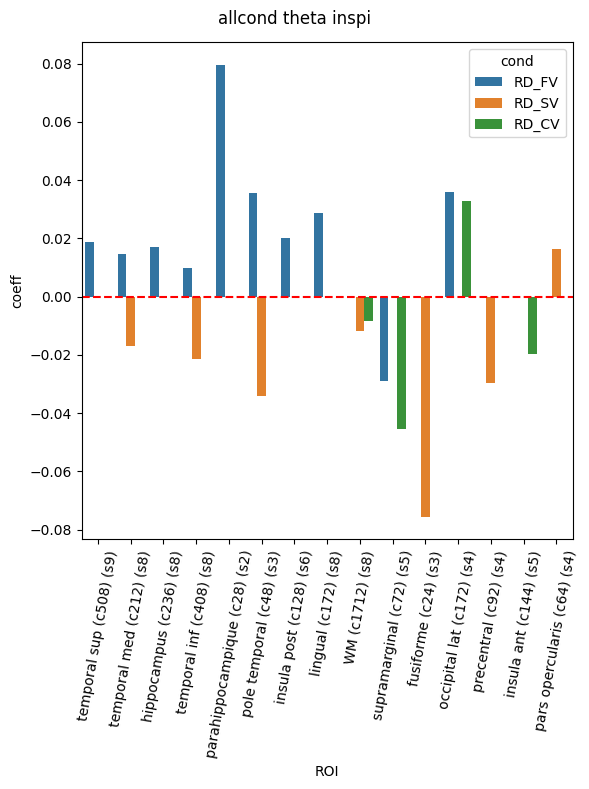

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


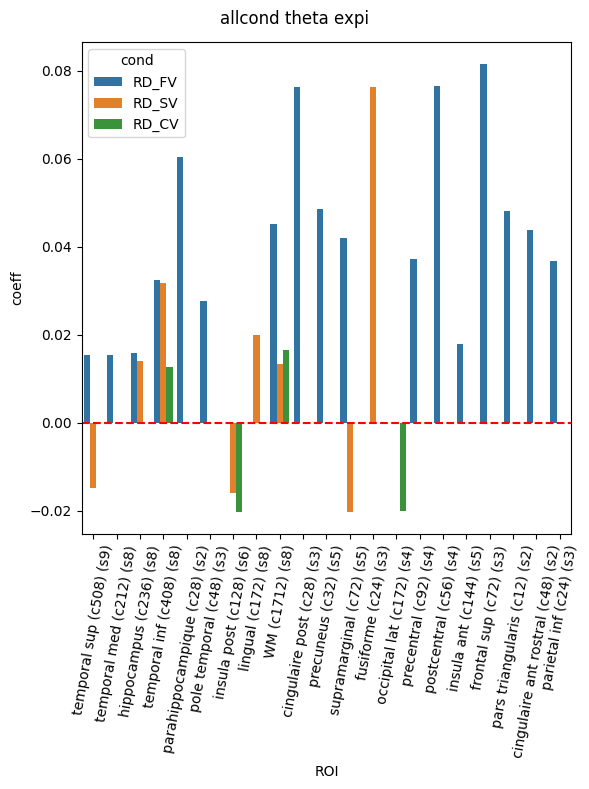

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


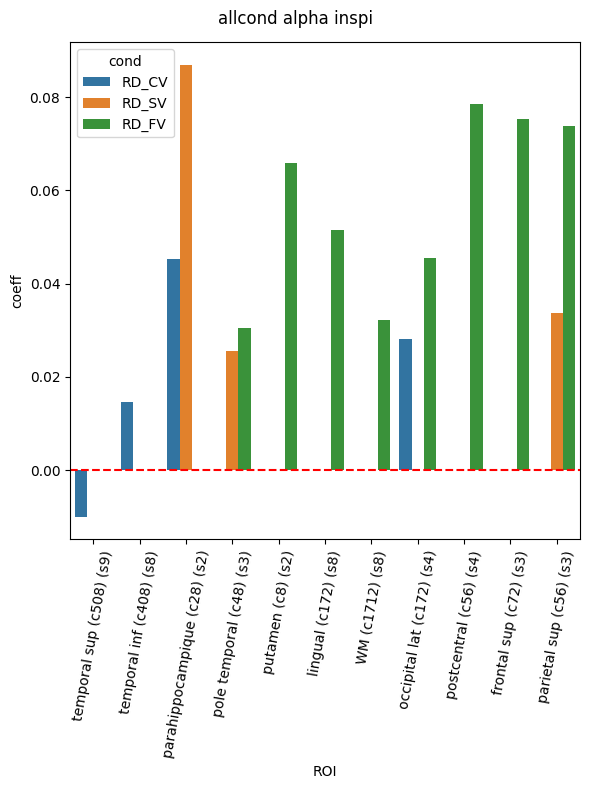

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


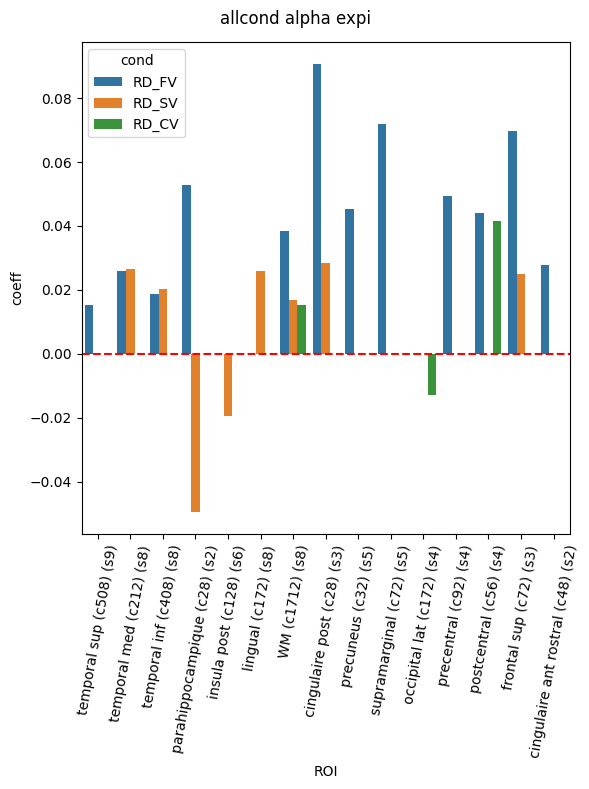

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


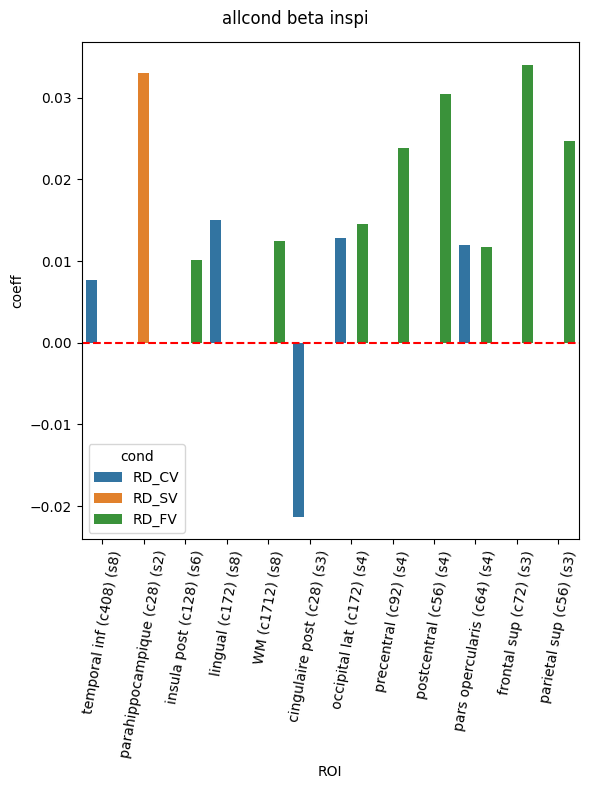

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


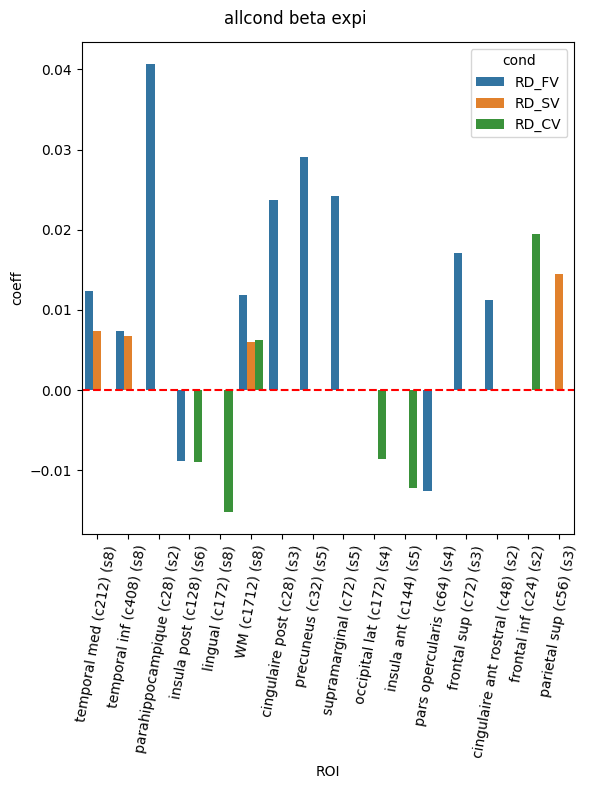

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


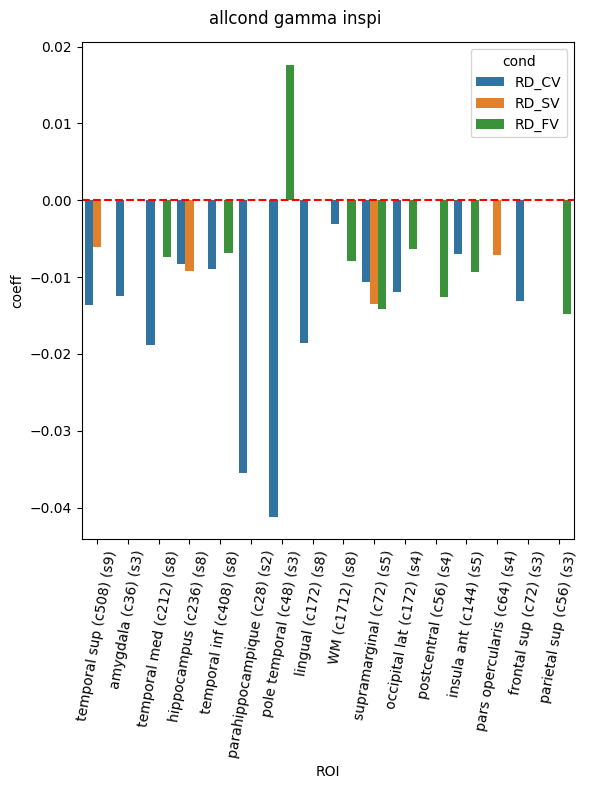

/tmp/ipykernel_5954/1767849866.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


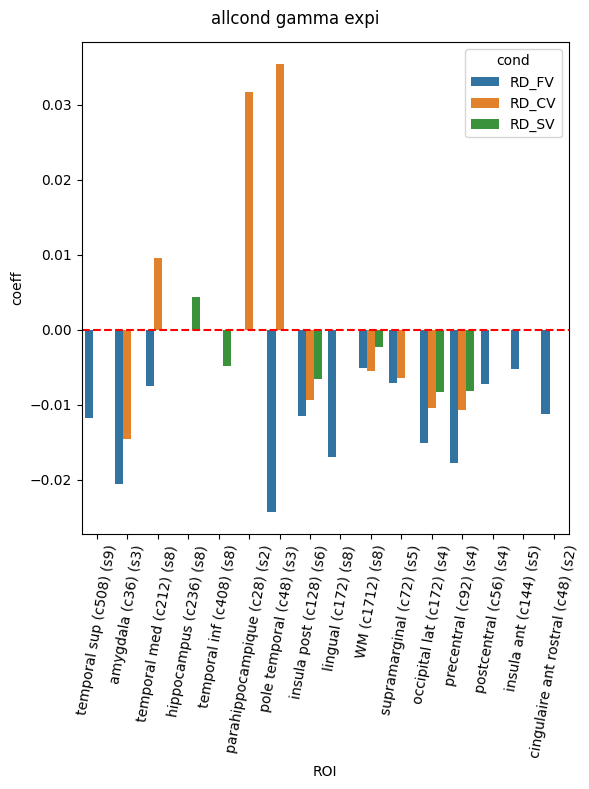

In [98]:
for band in freq_band_dict_FC_lmm['wb']:

    for phase in ['inspi', 'expi']:

        df_plot = df_lmm_allcond_summary.query(f"band == '{band}' and phase == '{phase}' and p == 1")

        ROI_labels = []
        for ROI in df_plot['ROI'].unique():
            _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
            _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
            ROI_labels.append(f"{ROI} (c{_count_plot}) (s{_count_sujet})")

        plt.figure(figsize=(6, 8))
        ax = sns.barplot(data=df_plot, x='ROI', y='coeff', hue='cond')
        ax.axhline(0, color='r', linestyle='--')
        ax.set_xticklabels(ROI_labels, rotation=80)
        plt.suptitle(f"allcond {band} {phase}")
        plt.tight_layout()
        plt.show()

### Spearman allplot

In [100]:
def spearman_permutation_test(x, y, n_perm, percentile_thresh_list):

    rho_obs, _ = scipy.stats.spearmanr(x, y)

    null_dist = np.zeros(n_perm)
    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        null_dist[i], _ = scipy.stats.spearmanr(x, y_perm)

    signi = rho_obs > np.percentile(null_dist, percentile_thresh_list[1]) or rho_obs < np.percentile(null_dist, percentile_thresh_list[0])

    return rho_obs, signi

percentile_thresh_list = [2.5, 97.5]
n_perm_spearman = 500

data = {'ROI': [], 'band' : [], 'phase' : [], 'rho': [], 'signi': []}

for ROI in ROI_list_allcond_filt:

    for band in freq_band_dict_FC_lmm['wb']:

        for phase in ['inspi', 'expi']:

            _df = df_Pxx_allcond_filt.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")[['Pxx', 'resp']]

            x = _df['resp'].values
            y = _df['Pxx'].values

            rho, signi = spearman_permutation_test(x, y, n_perm_spearman, percentile_thresh_list)

            data['ROI'].append(ROI)
            data['band'].append(band)
            data['phase'].append(phase)
            data['rho'].append(rho)
            data['signi'].append(signi)

# Build dataframe
df_spearman = pd.DataFrame(data)

/tmp/ipykernel_5954/1980368432.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


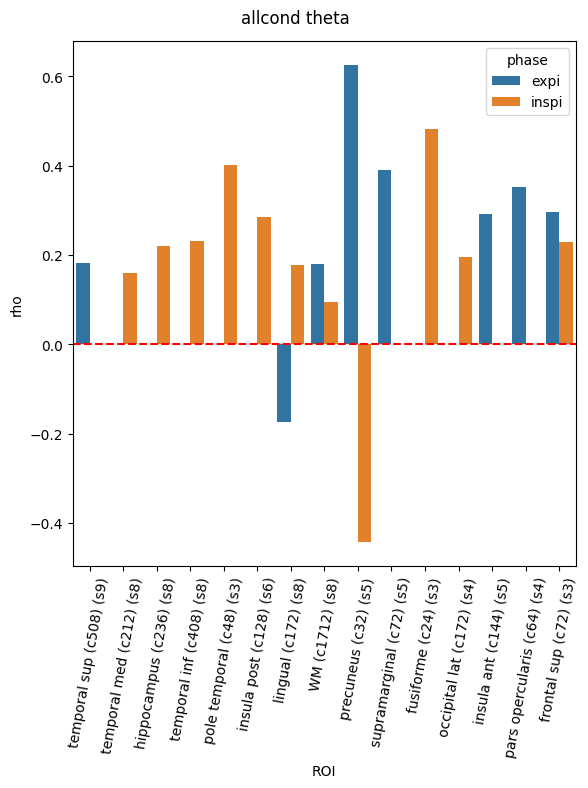

/tmp/ipykernel_5954/1980368432.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


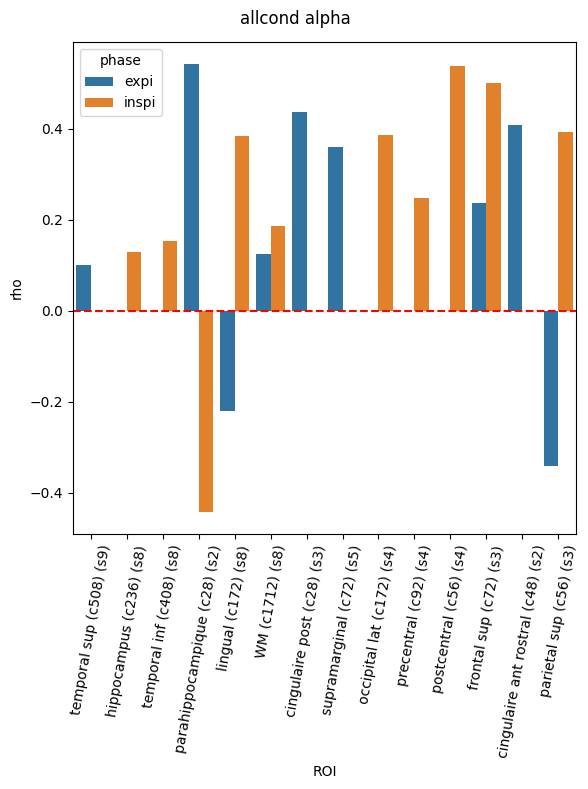

/tmp/ipykernel_5954/1980368432.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


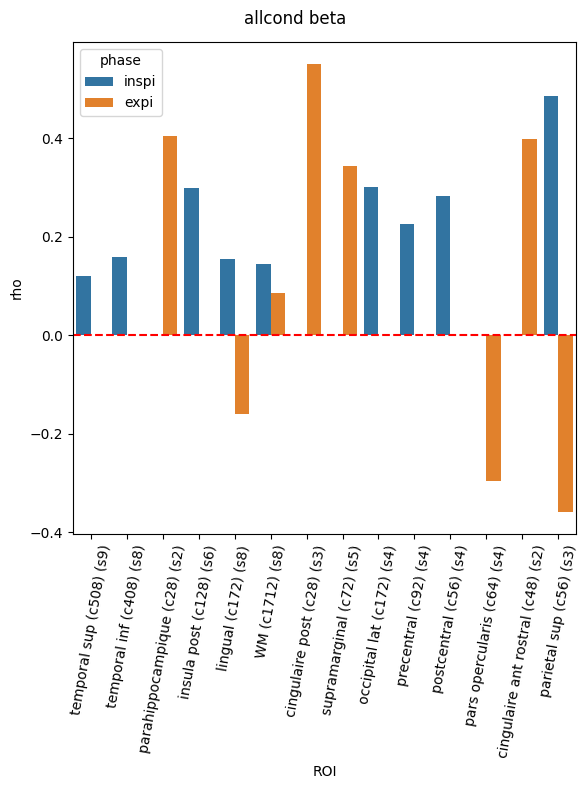

/tmp/ipykernel_5954/1980368432.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROI_labels, rotation=80)


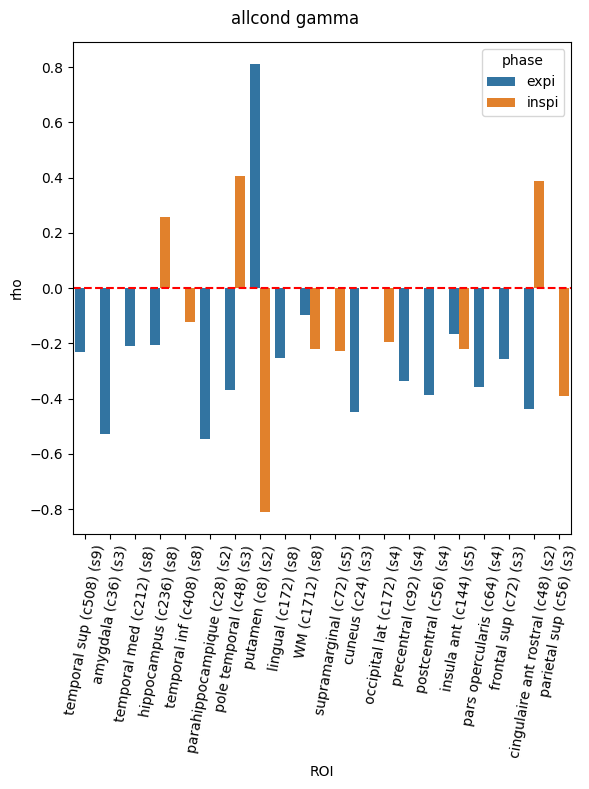

In [104]:
for band in freq_band_dict_FC_lmm['wb']:

    df_plot = df_spearman.query(f"signi == True and band == '{band}'")

    ROI_labels = []
    for ROI in df_plot['ROI'].unique():
        _count_plot = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
        _count_sujet = df_ROI_count_allcond.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
        ROI_labels.append(f"{ROI} (c{_count_plot}) (s{_count_sujet})")

    plt.figure(figsize=(6, 8))
    ax = sns.barplot(data=df_plot, x='ROI', y='rho', hue='phase')
    ax.axhline(0, color='r', linestyle='--')
    ax.set_xticklabels(ROI_labels, rotation=80)
    plt.suptitle(f"allcond {band}")
    plt.tight_layout()
    plt.show()

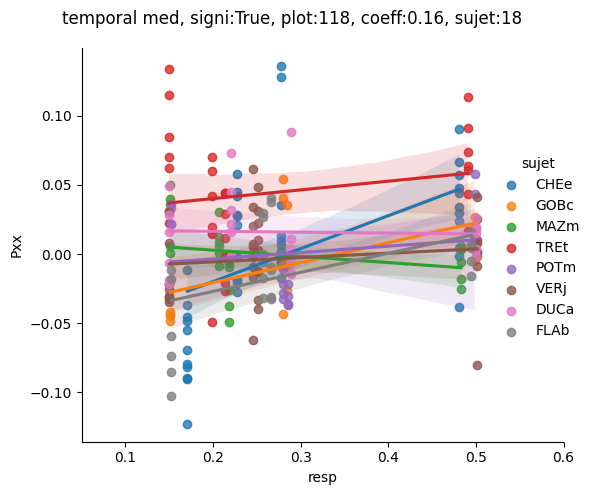

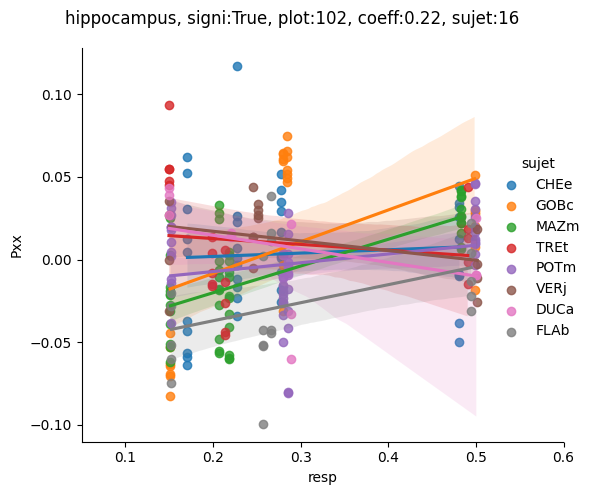

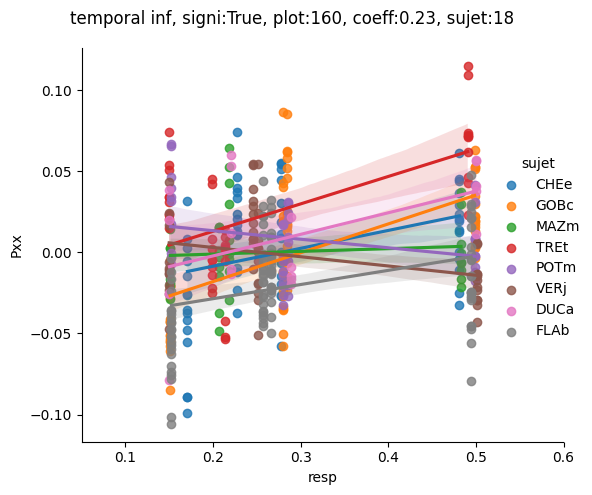

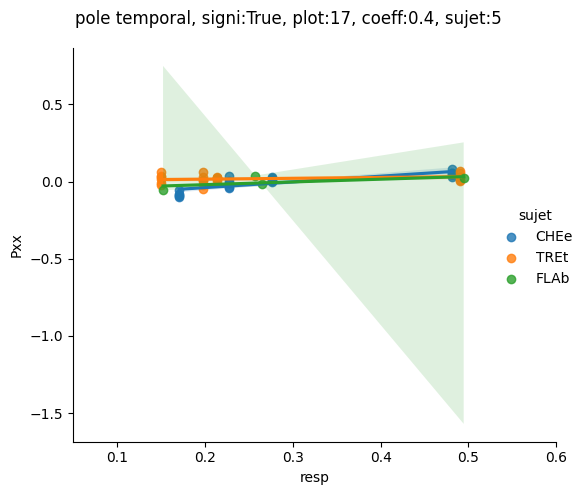

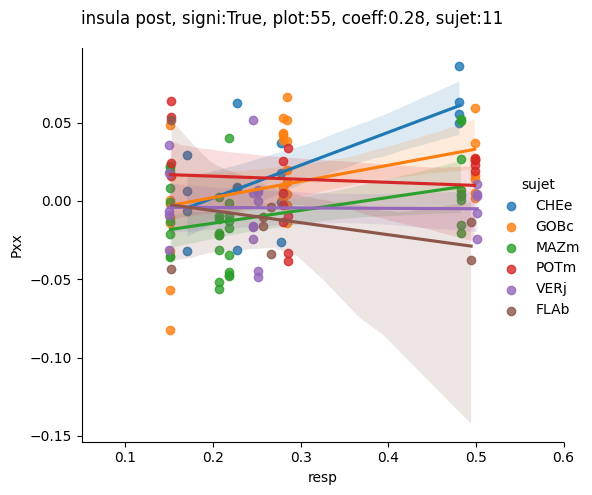

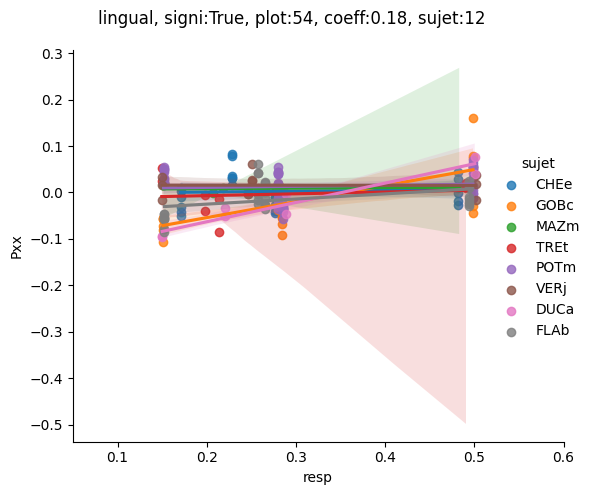

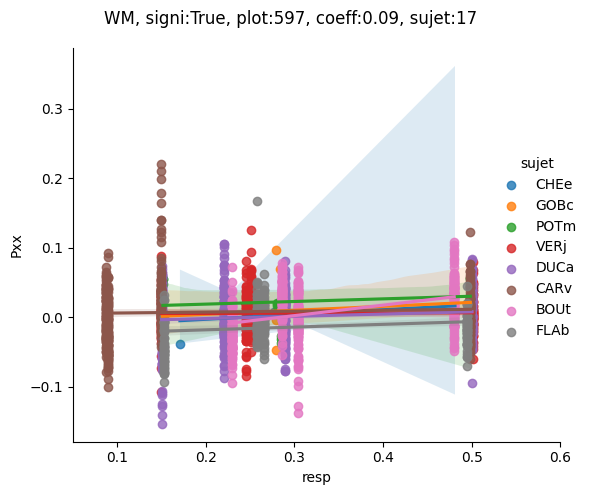

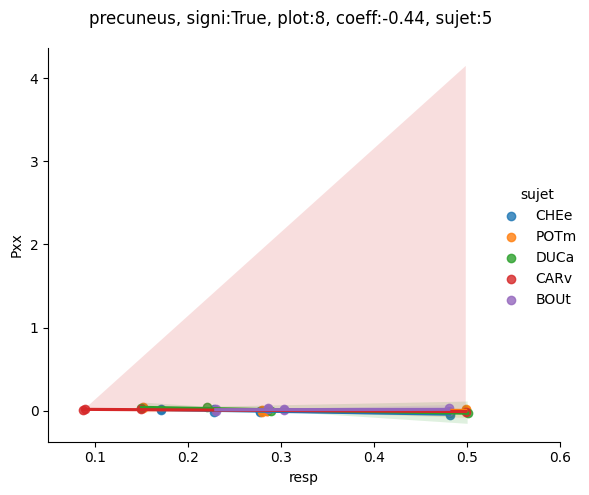

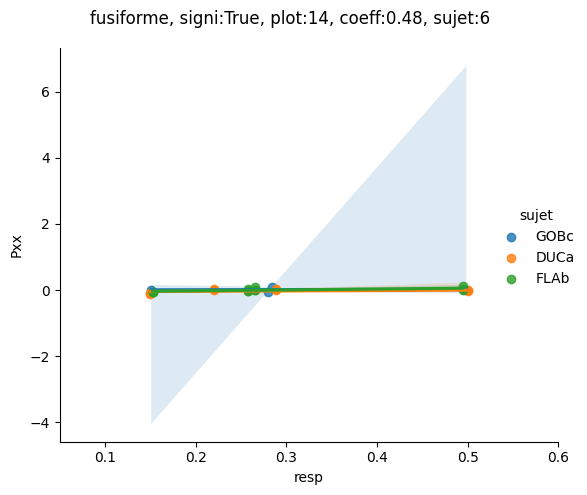

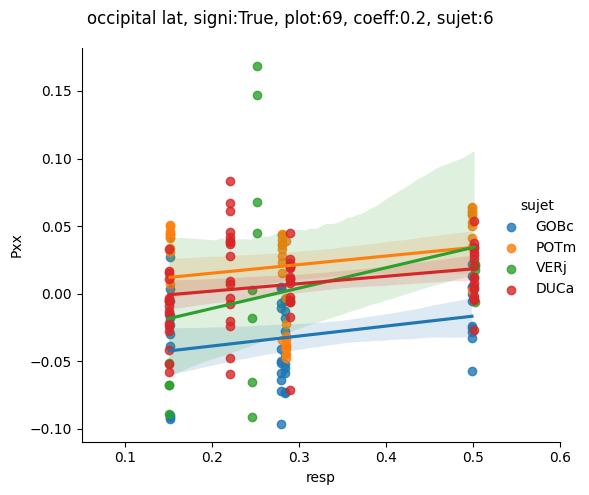

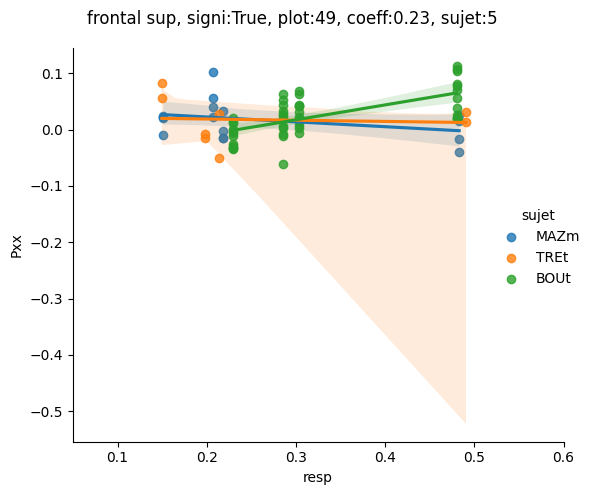

In [107]:
band = 'theta'
phase = 'inspi'

df_select_signi = df_spearman.query(f"signi == True and band == '{band}' and phase == '{phase}'")

for ROI in df_select_signi['ROI'].unique():
    
    df_plot = df_Pxx_allcond_filt.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")
    sns.lmplot(x="resp", y="Pxx", hue='sujet', data=df_plot)
    _coeff = df_spearman.query(f"ROI == '{ROI}' and band == '{band}' and phase == '{phase}'")['rho'].values[0]
    plt.xlim(0.05,0.6)
    _count_plot = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_plot'].iloc[0]
    _count_sujet = df_ROI_count_FR_CV.query(f"ROI == '{ROI}'")['count_sujet'].iloc[0]
    plt.suptitle(f"{ROI}, signi:True, plot:{_count_plot}, coeff:{np.round(_coeff, 2)}, sujet:{_count_sujet}")
    plt.tight_layout()

# DFC

## FR_CV

In [12]:
df_Cxy_FR_CV_filt['ROI'].unique()

array(['temporal sup', 'amygdala', 'temporal med', 'hippocampus',
       'temporal inf', 'parahippocampique', 'pole temporal',
       'insula post', 'lingual', 'WM', 'cingulaire post', 'precuneus',
       'supramarginal', 'fusiforme', 'cuneus', 'occipital lat',
       'precentral', 'postcentral', 'insula ant', 'pars opercularis',
       'frontal sup', 'orbitofrontal', 'pars orbitalis',
       'pars triangularis', 'cingulaire ant rostral', 'frontal inf',
       'parietal inf', 'parietal sup', 'frontal med',
       'cingulaire ant caudal'], dtype=object)

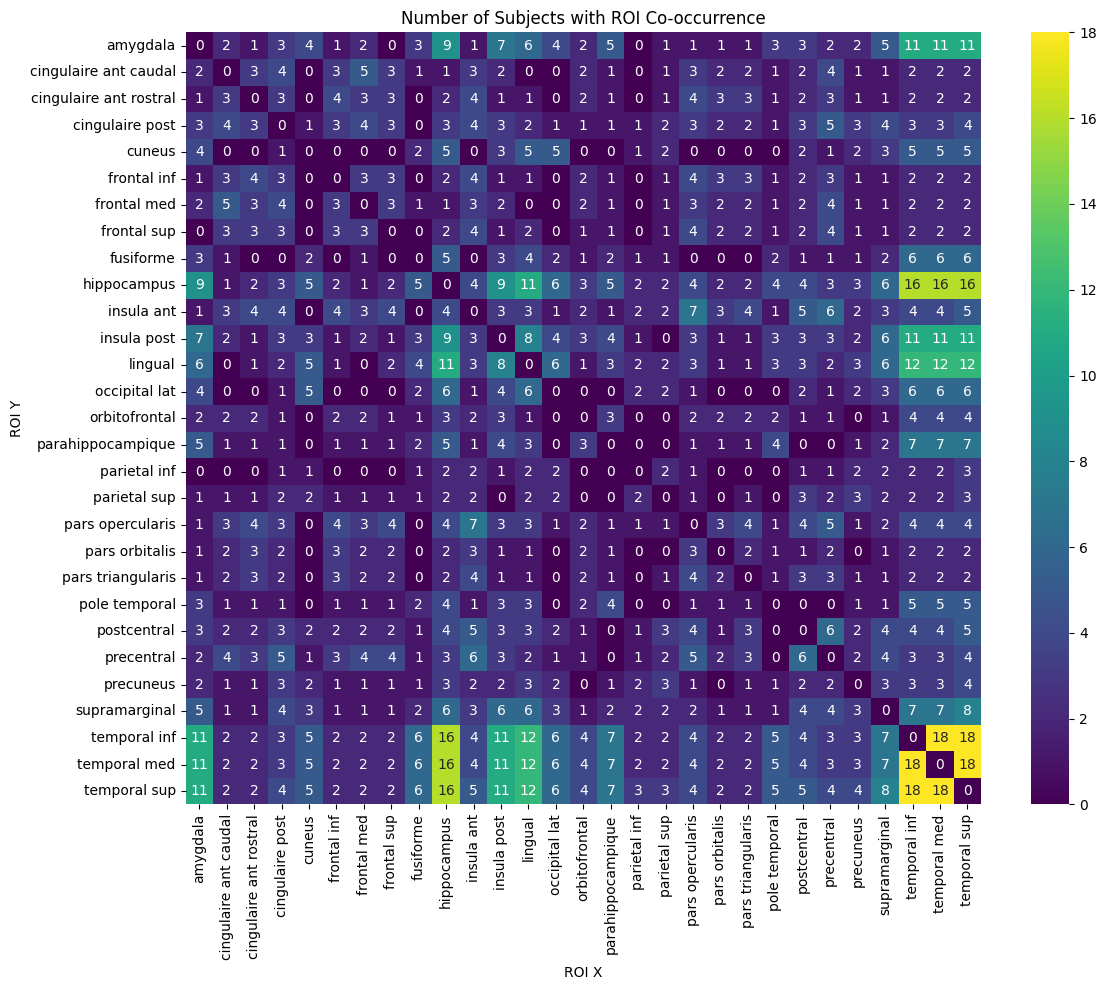

In [14]:
sujet_roi_map = df_Cxy_FR_CV_filt.query(f"ROI != 'WM'").groupby('sujet')['ROI'].unique()

# Get the full unique ROI list
all_rois = np.unique(df_Cxy_FR_CV_filt.query(f"ROI != 'WM'")['ROI'])

# Create an empty DataFrame to store counts
roi_matrix = pd.DataFrame(0, index=all_rois, columns=all_rois)

# Count co-occurrence
for rois in sujet_roi_map:
    for roi1 in rois:
        for roi2 in rois:
            if roi1 == roi2:
                continue
            roi_matrix.loc[roi1, roi2] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(roi_matrix, annot=True, fmt="d", cmap="viridis")
plt.title("Number of Subjects with ROI Co-occurrence")
plt.ylabel("ROI Y")
plt.xlabel("ROI X")
plt.tight_layout()
plt.show()

In [16]:
ROI_dfc = ['amygdala', 'hippocampus']
df_Cxy_FR_CV_filt.query(f"ROI in {ROI_dfc}").groupby(['sujet', 'ROI']).count().groupby(['sujet']).count().query(f"cond >= {len(ROI_dfc)}").reset_index()['sujet'].iloc[:]

0              BANc
1              CHEe
2              GOBc
3              LEMl
4              MUGa
5              POTm
6    pat_03083_1527
7    pat_03105_1551
8    pat_03174_1634
Name: sujet, dtype: object

## ALL CONDITIONS

### ANATOMY

In [108]:
df_Cxy_allcond_filt['ROI'].unique()

array(['temporal sup', 'amygdala', 'temporal med', 'hippocampus',
       'temporal inf', 'parahippocampique', 'pole temporal', 'putamen',
       'insula post', 'lingual', 'WM', 'cingulaire post', 'precuneus',
       'supramarginal', 'fusiforme', 'cuneus', 'occipital lat',
       'precentral', 'postcentral', 'insula ant', 'pars opercularis',
       'frontal sup', 'pars triangularis', 'cingulaire ant rostral',
       'frontal inf', 'parietal inf', 'parietal sup'], dtype=object)

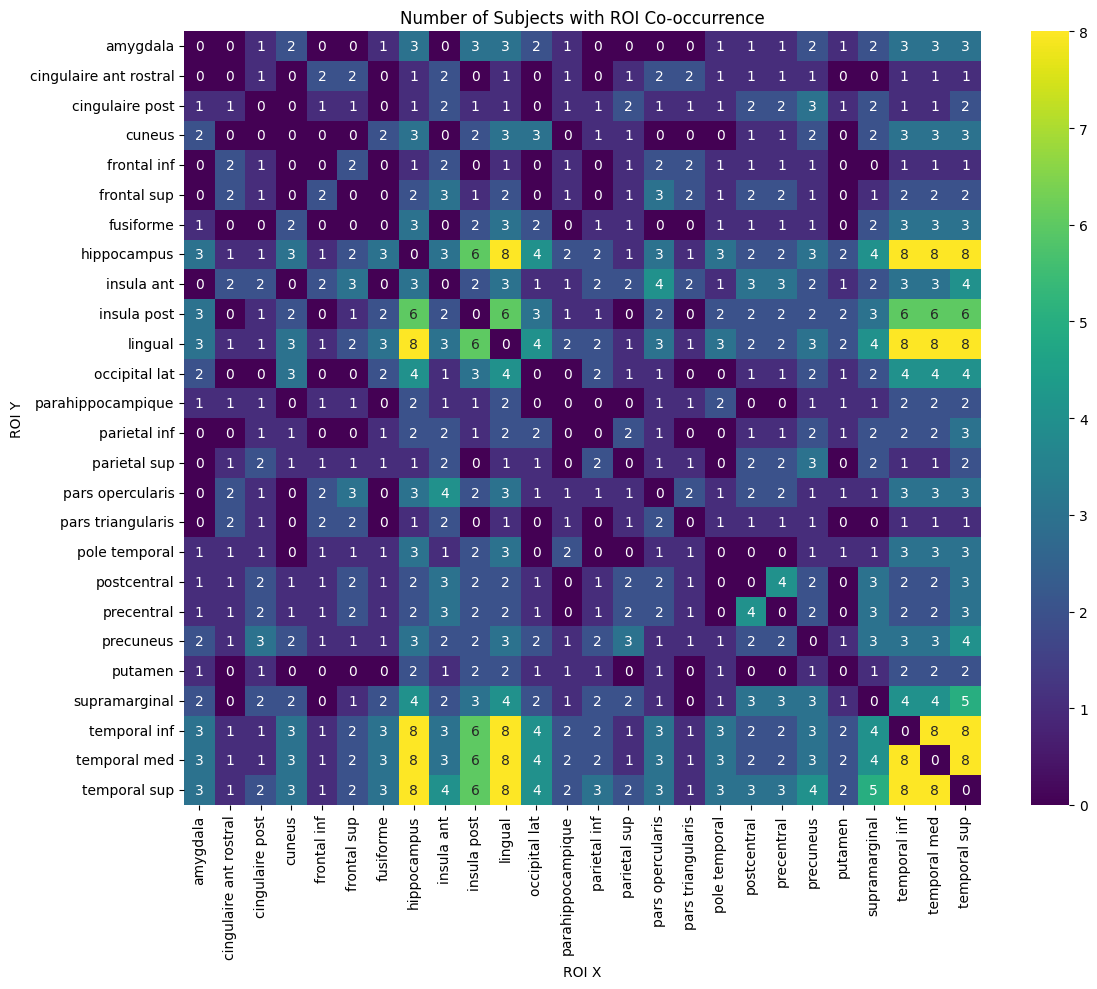

In [147]:
sujet_roi_map = df_Cxy_allcond_filt.query(f"ROI != 'WM'").groupby('sujet')['ROI'].unique()

# Get the full unique ROI list
all_rois = np.unique(df_Cxy_allcond_filt.query(f"ROI != 'WM'")['ROI'])

# Create an empty DataFrame to store counts
roi_matrix = pd.DataFrame(0, index=all_rois, columns=all_rois)

# Count co-occurrence
for rois in sujet_roi_map:
    for roi1 in rois:
        for roi2 in rois:
            if roi1 == roi2:
                continue
            roi_matrix.loc[roi1, roi2] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(roi_matrix, annot=True, fmt="d", cmap="viridis")
plt.title("Number of Subjects with ROI Co-occurrence")
plt.ylabel("ROI Y")
plt.xlabel("ROI X")
plt.tight_layout()
plt.show()

In [126]:
ROI_dfc = ['frontal sup', 'frontal inf']
df_Cxy_allcond_filt.query(f"ROI in {ROI_dfc}").groupby(['sujet', 'ROI']).count().groupby(['sujet']).count().query(f"cond >= {len(ROI_dfc)}").reset_index()['sujet'].iloc[:]

0    BOUt
1    TREt
Name: sujet, dtype: object

In [149]:
ROI_dfc = ['amygdala', 'hippocampus', 'insula post']
df_Cxy_allcond_filt.query(f"ROI in {ROI_dfc}").groupby(['sujet', 'ROI']).count().groupby(['sujet']).count().query(f"cond >= {len(ROI_dfc)}").reset_index()['sujet'].iloc[:]

0    CHEe
1    GOBc
2    POTm
Name: sujet, dtype: object

In [154]:
ROI_dfc = ['amygdala', 'hippocampus', 'insula post']
sujet_sel_dfc = ['CHEe', 'GOBc', 'POTm']
df_Cxy_allcond_filt.query(f"ROI in {ROI_dfc} and sujet in {sujet_sel_dfc}").groupby(['sujet', 'ROI']).count()['cond']

sujet  ROI        
CHEe   amygdala        4
       hippocampus    40
       insula post    16
GOBc   amygdala       16
       hippocampus    28
       insula post    32
POTm   amygdala       16
       hippocampus    52
       insula post    16
Name: cond, dtype: int64